# <p style="font-family: Cambria; text-align: center; font-size: 44px;">IV. PREDICTIVE ANALYSIS</p>



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())

Dataset shape: (2008, 210)
Unique patients: 2008


<p style="font-family: Cambria; font-size: 16px;"><b>Shared helper functions and chart colours</b></p>

In [2]:
def build_logistic_model(features, categorical_features):

    # Keep only categorical columns included in the feature list
    categorical_features = [
        col for col in categorical_features
        if col in features
    ]

    # Remaining columns are treated as numeric
    numeric_features = [
        col for col in features
        if col not in categorical_features
    ]

    transformers = []

    # -----------------------------
    # Numeric preprocessing
    # -----------------------------
    if numeric_features:

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        transformers.append(
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            )
        )

    # -----------------------------
    # Categorical preprocessing
    # -----------------------------
    if categorical_features:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    # -----------------------------
    # Preprocessor
    # -----------------------------
    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    # -----------------------------
    # Final ML pipeline
    # -----------------------------
    model = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    return model


print("\nPredictive analysis setup completed successfully!")


Predictive analysis setup completed successfully!


In [3]:
cols = ["#6daa9f", "#774571", "#6daa9f", "#774571"]   # palette used in Q9-Q12

# ---------- Same colour system as the descriptive notebook ----------
INK, MUTED, GRID = "#1f1f1f", "#6b6b6b", "#e6e6e6"
BLUE    = "#2a78d6"   # single series, and "Readmission"
ORANGE  = "#eb6834"   # second series, and "Death"
REF     = "#d03b3b"   # reference lines only (coin-toss line, cut-offs)
NEUTRAL = "#b8b6b0"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
def ramp(n):
    """n evenly spaced steps from the blue ramp (light -> dark)."""
    return [RAMP[i] for i in np.linspace(0, len(RAMP) - 1, n).round().astype(int)]

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#bdbdbd", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "legend.frameon": False})

def label_bars(ax, fmt="{:.1f}%"):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v) for v in c.datavalues], padding=3, fontsize=9, color=INK)

def suptitle(fig, text):
    fig.suptitle(text, fontsize=14, fontweight="bold", x=0.06, ha="left", y=1.02)

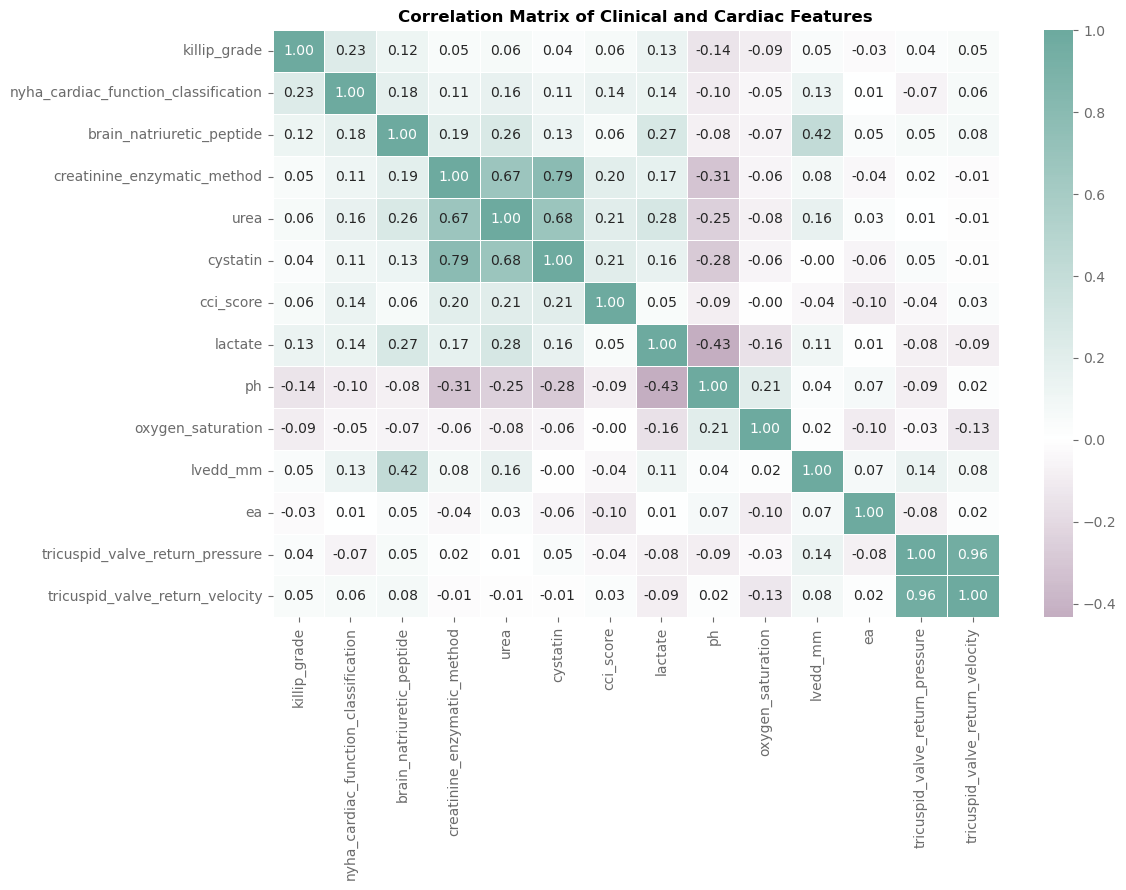

In [4]:
# Examining a Correlation Matrix of All Features

# Admission-time clinical and cardiac features
corr_features = [
    "killip_grade",
    "nyha_cardiac_function_classification",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "urea",
    "cystatin",
    "cci_score",
    "lactate",
    "ph",
    "oxygen_saturation",
    "lvedd_mm",
    "ea",
    "tricuspid_valve_return_pressure",
    "tricuspid_valve_return_velocity"
]

corr_data = df[corr_features].apply(pd.to_numeric, errors="coerce").corr()

cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#774571", "white", "#6daa9f"]
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Clinical and Cardiac Features")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The correlation matrix shows the strength and direction of relationships among the selected clinical and cardiac features. Most features have weak-to-moderate correlations, indicating that they capture different aspects of patient condition. Some stronger relationships can be observed among related cardiac and renal measurements, suggesting overlapping clinical information. Overall, the matrix helps identify related variables and potential multicollinearity before building predictive models.</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q1. Can demographic characteristics such as age, gender, weight, height, BMI, and occupation be used to predict the risk of in-hospital mortality among patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>agecat</code>, <code>gender</code>, <code>weight</code>, <code>height</code>, <code>bmi</code>, <code>occupation</code>, <code>outcome_during_hospitalization</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Demographic characteristics may contain information related to mortality risk, but they do not directly measure heart-failure severity. This question tests whether age group, gender, body measurements and occupation can distinguish patients who die during hospitalization from those who survive. Because in-hospital mortality is rare, a class-balanced Logistic Regression model is used and performance is interpreted using ROC-AUC, recall, precision, F1-score and the confusion matrix rather than accuracy alone.
</i></b></p>


In [5]:
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

features_q1 = ["agecat", "gender", "weight", "height", "bmi", "occupation"]
X1 = df[features_q1]
y1 = df["in_hospital_death"]

num1 = ["weight", "height", "bmi"]
cat1 = ["agecat", "gender", "occupation"]

prep1 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num1),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat1)
])

model_q1 = Pipeline([
    ("preprocessor", prep1),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

model_q1.fit(X1_train, y1_train)
pred1 = model_q1.predict(X1_test)
prob1 = model_q1.predict_proba(X1_test)[:, 1]
auc1 = roc_auc_score(y1_test, prob1)

print("In-hospital deaths:", int(y1.sum()), "of", len(y1))
print(classification_report(y1_test, pred1, zero_division=0))
print("ROC-AUC:", round(auc1, 3))
print("Confusion Matrix:\n", confusion_matrix(y1_test, pred1))

In-hospital deaths: 11 of 2008
              precision    recall  f1-score   support

           0       1.00      0.71      0.83       600
           1       0.02      1.00      0.03         3

    accuracy                           0.71       603
   macro avg       0.51      0.86      0.43       603
weighted avg       1.00      0.71      0.83       603

ROC-AUC: 0.91
Confusion Matrix:
 [[428 172]
 [  0   3]]


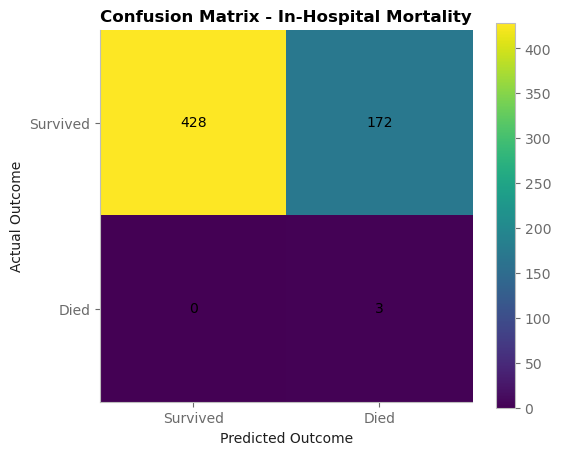

In [6]:
# Confusion Matrix Heatmap
cm1 = confusion_matrix(y1_test, pred1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm1)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Survived", "Died"])
ax.set_yticklabels(["Survived", "Died"])
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")
ax.set_title("Confusion Matrix - In-Hospital Mortality")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm1[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The confusion matrix shows that the demographic model correctly identified all 3 in-hospital deaths in the test set, but it also incorrectly classified 172 surviving patients as deaths. Although the model achieved a ROC-AUC of 0.910 and mortality recall of 1.00, mortality precision was only 0.02. This means the model was sensitive to the very small death group but generated many false-positive alerts. Because only 11 of 2,008 patients died during hospitalization, demographic characteristics alone should be treated as exploratory predictors and are not sufficient as a reliable standalone mortality model.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q2. Can demographic and baseline clinical characteristics be used to predict the risk of 28-day mortality among patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>agecat</code>, <code>gender</code>, <code>bmi</code>, <code>admission_way</code>, <code>nyha_cardiac_function_classification</code>, <code>killip_grade</code>, <code>lvef</code>, <code>systolic_blood_pressure</code>, <code>pulse</code>, <code>cci_score</code>, <code>death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Twenty-eight-day mortality reflects short-term risk after hospitalization. Demographics alone may not capture the patient's clinical condition, so this model adds admission type, cardiac severity, LVEF, systolic blood pressure, pulse and comorbidity burden. The objective is to determine whether this combined baseline profile can distinguish patients who die within 28 days from those who survive.
</i></b></p>


In [7]:
features_q2 = [
    "agecat", "gender", "bmi", "admission_way",
    "nyha_cardiac_function_classification", "killip_grade",
    "lvef", "systolic_blood_pressure", "pulse", "cci_score"
]
X2 = df[features_q2]
y2 = df["death_within_28_days"]

num2 = ["bmi", "nyha_cardiac_function_classification", "killip_grade",
        "lvef", "systolic_blood_pressure", "pulse", "cci_score"]
cat2 = ["agecat", "gender", "admission_way"]

prep2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat2)
])

model_q2 = Pipeline([
    ("preprocessor", prep2),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

model_q2.fit(X2_train, y2_train)
pred2 = model_q2.predict(X2_test)
prob2 = model_q2.predict_proba(X2_test)[:, 1]
auc2 = roc_auc_score(y2_test, prob2)

print("28-day deaths:", int(y2.sum()), "of", len(y2))
print(classification_report(y2_test, pred2, zero_division=0))
print("ROC-AUC:", round(auc2, 3))
print("Confusion Matrix:\n", confusion_matrix(y2_test, pred2))

28-day deaths: 37 of 2008
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       592
           1       0.05      0.55      0.10        11

    accuracy                           0.81       603
   macro avg       0.52      0.68      0.49       603
weighted avg       0.97      0.81      0.88       603

ROC-AUC: 0.771
Confusion Matrix:
 [[483 109]
 [  5   6]]


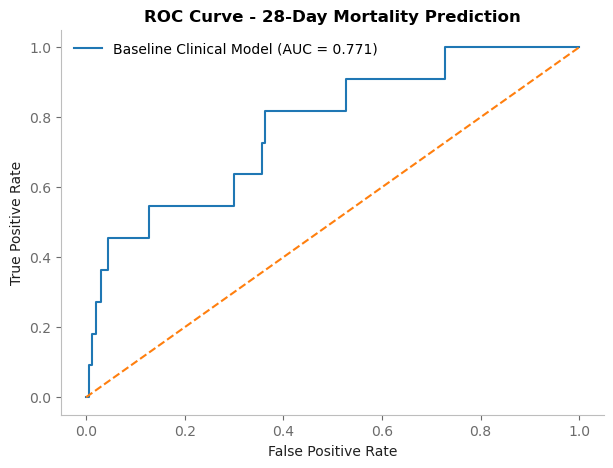

In [8]:
# ROC Curve
fpr2, tpr2, _ = roc_curve(y2_test, prob2)

plt.figure(figsize=(7, 5))
plt.plot(fpr2, tpr2, label=f"Baseline Clinical Model (AUC = {auc2:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 28-Day Mortality Prediction")
plt.legend()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The ROC curve shows that the combined demographic and baseline clinical model achieved a ROC-AUC of 0.771 for predicting 28-day mortality, indicating useful but not strong discrimination between patients who died and those who survived. The model correctly identified 6 of the 11 deaths in the test set, giving a mortality recall of 0.55, but precision was only 0.05 because many surviving patients were also classified as high risk. These results suggest that demographics, cardiac severity, vital signs and comorbidity together provide some predictive information for short-term mortality, but the small number of deaths means the model should be interpreted cautiously.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q3. Can NYHA functional class and Killip grade together predict 28-day mortality better than either heart-failure severity measure alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>nyha_cardiac_function_classification</code>, <code>killip_grade</code>, <code>death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
NYHA functional class and Killip grade measure different aspects of heart-failure severity. Three predictive models are compared: NYHA alone, Killip alone, and NYHA plus Killip. All models use the same train/test split so their ROC-AUC values can be compared fairly. If the combined model performs better, it suggests that the two severity measures provide complementary predictive information.
</i></b></p>


In [9]:
y3 = df["death_within_28_days"]

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.30, random_state=42, stratify=y3
)

def severity_model(features):
    X = df[features]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y3.iloc[train_idx], y3.iloc[test_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    return model, probability, roc_auc_score(y_test, probability)

nyha_model, nyha_prob, nyha_auc = severity_model(
    ["nyha_cardiac_function_classification"]
)
killip_model, killip_prob, killip_auc = severity_model(
    ["killip_grade"]
)
combined_model, combined_prob, combined_auc = severity_model(
    ["nyha_cardiac_function_classification", "killip_grade"]
)

results_q3 = pd.DataFrame({
    "Model": ["NYHA", "Killip", "NYHA + Killip"],
    "ROC-AUC": [nyha_auc, killip_auc, combined_auc]
})
display(results_q3.round(3))

,Model,ROC-AUC
0,NYHA,0.694
1,Killip,0.772
2,NYHA + Killip,0.807


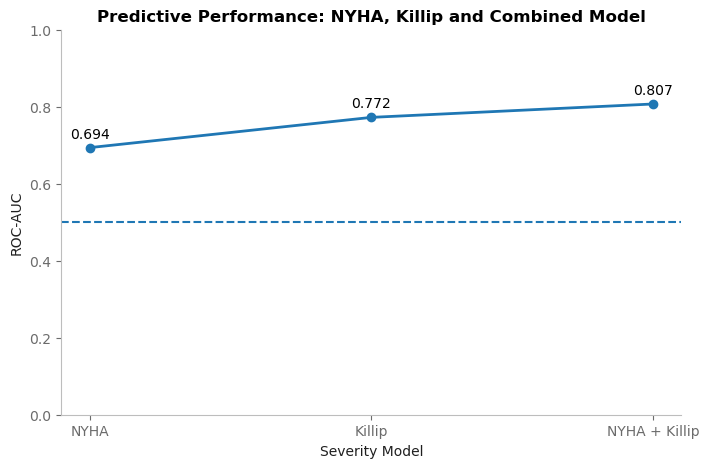

In [10]:
# Line chart comparing the three severity models
plt.figure(figsize=(8, 5))
plt.plot(
    results_q3["Model"],
    results_q3["ROC-AUC"],
    marker="o",
    linewidth=2
)
plt.axhline(0.5, linestyle="--")
plt.ylabel("ROC-AUC")
plt.xlabel("Severity Model")
plt.title("Predictive Performance: NYHA, Killip and Combined Model")
plt.ylim(0, 1)

for x, y in zip(results_q3["Model"], results_q3["ROC-AUC"]):
    plt.text(x, y + 0.025, f"{y:.3f}", ha="center")

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The model-comparison chart shows that NYHA alone produced a ROC-AUC of 0.694, Killip grade alone produced 0.772, and the combined NYHA + Killip model produced the highest ROC-AUC at 0.807. The combined model improved AUC by 0.113 compared with NYHA alone and by 0.035 compared with Killip alone. This suggests that NYHA and Killip provide complementary information for predicting 28-day mortality, with the combined severity model showing the strongest discrimination of the three in this test split.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q4. Can renal-function markers predict 6-month mortality and 6-month readmission in patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>creatinine_enzymatic_method</code>, <code>urea</code>, <code>uric_acid</code>, <code>glomerular_filtration_rate</code>, <code>cystatin</code>, <code>acute_renal_failure</code>, <code>moderate_to_severe_chronic_kidney_disease</code>, <code>death_within_6_months</code>, <code>re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Kidney dysfunction commonly accompanies severe heart failure and may provide prognostic information. Creatinine, urea, uric acid, GFR and cystatin represent different aspects of renal function, while acute renal failure and moderate-to-severe chronic kidney disease represent diagnosed renal impairment. Separate prediction models are built for 6-month mortality and 6-month readmission to determine whether a renal-only profile can discriminate both outcomes.
</i></b></p>


In [11]:
renal_features = [
    "creatinine_enzymatic_method", "urea", "uric_acid",
    "glomerular_filtration_rate", "cystatin",
    "acute_renal_failure", "moderate_to_severe_chronic_kidney_disease"
]

def renal_model(outcome):
    X = df[renal_features]
    y = df[outcome]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    return model, y_test, pred, prob, auc

mort_model4, mort_y4, mort_pred4, mort_prob4, mort_auc4 = renal_model(
    "death_within_6_months"
)
readm_model4, readm_y4, readm_pred4, readm_prob4, readm_auc4 = renal_model(
    "re_admission_within_6_months"
)

results_q4 = pd.DataFrame({
    "Outcome": ["6-Month Mortality", "6-Month Readmission"],
    "ROC-AUC": [mort_auc4, readm_auc4]
})
display(results_q4.round(3))

print("\n6-Month Mortality")
print(classification_report(mort_y4, mort_pred4, zero_division=0))
print("\n6-Month Readmission")
print(classification_report(readm_y4, readm_pred4, zero_division=0))

,Outcome,ROC-AUC
0,6-Month Mortality,0.586
1,6-Month Readmission,0.576



6-Month Mortality
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       586
           1       0.07      0.41      0.12        17

    accuracy                           0.82       603
   macro avg       0.52      0.62      0.51       603
weighted avg       0.95      0.82      0.88       603


6-Month Readmission
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       371
           1       0.45      0.47      0.46       232

    accuracy                           0.58       603
   macro avg       0.56      0.56      0.56       603
weighted avg       0.58      0.58      0.58       603



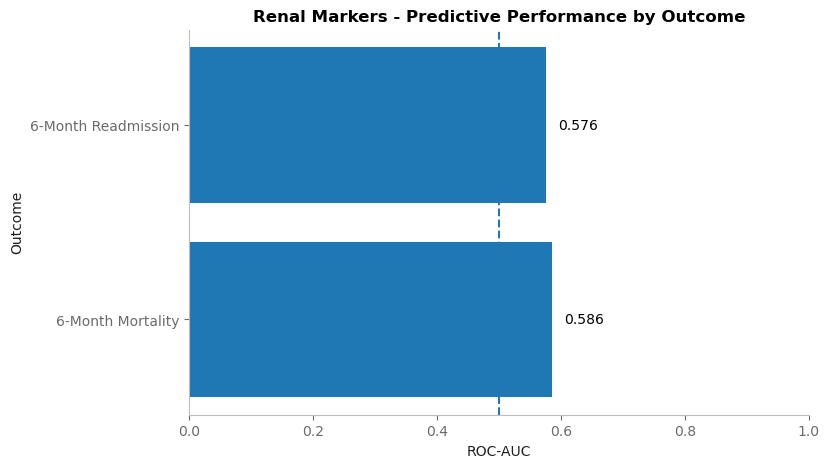

In [12]:
# Horizontal bar chart comparing renal-model performance
plt.figure(figsize=(8, 5))
plt.barh(results_q4["Outcome"], results_q4["ROC-AUC"])
plt.axvline(0.5, linestyle="--")
plt.xlabel("ROC-AUC")
plt.ylabel("Outcome")
plt.title("Renal Markers - Predictive Performance by Outcome")
plt.xlim(0, 1)

for i, value in enumerate(results_q4["ROC-AUC"]):
    plt.text(value + 0.02, i, f"{value:.3f}", va="center")

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The horizontal bar chart shows that renal-function markers produced a ROC-AUC of 0.586 for 6-month mortality and 0.576 for 6-month readmission. Both values are only slightly above the 0.50 reference level, indicating weak predictive discrimination when renal markers are used alone. The mortality model performed only marginally better than the readmission model, with an AUC difference of 0.010. These results suggest that renal markers may contribute useful risk information, but they are not strong standalone predictors and would be better combined with cardiac severity, biomarkers, comorbidities and other clinical characteristics.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q5. Do cardiac biomarkers such as BNP and troponin improve mortality prediction beyond demographic and clinical characteristics alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>agecat, gender, pulse, systolic_blood_pressure, nyha_cardiac_function_classification, killip_grade, brain_natriuretic_peptide, high_sensitivity_troponin, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>BNP reflects cardiac wall stress and fluid overload, while high-sensitivity troponin reflects myocardial injury. Demographic characteristics, vital signs and heart-failure severity already provide useful clinical information, so the objective is to determine whether these cardiac biomarkers add predictive value beyond the baseline clinical profile. Two models are compared: a baseline demographic and clinical model and an expanded model that adds BNP and troponin. ROC-AUC and precision-recall performance are used to evaluate whether the additional biomarker information improves mortality prediction.</b></i></p>

In [13]:
target_q5 = "death_within_6_months"

baseline_q5 = [
    "agecat",
    "gender",
    "pulse",
    "systolic_blood_pressure",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

expanded_q5 = baseline_q5 + [
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin"
]

categorical_q5 = [
    "agecat",
    "gender",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

q5 = df[expanded_q5 + [target_q5]].copy()

q5[target_q5] = pd.to_numeric(
    q5[target_q5], errors="coerce"
)

q5 = q5.dropna(subset=[target_q5])

X_q5 = q5[expanded_q5]
y_q5 = q5[target_q5].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_q5,
    y_q5,
    test_size=0.25,
    random_state=42,
    stratify=y_q5
)

baseline_model_q5 = build_logistic_model(
    baseline_q5,
    categorical_q5
)

expanded_model_q5 = build_logistic_model(
    expanded_q5,
    categorical_q5
)

baseline_model_q5.fit(
    X_train[baseline_q5],
    y_train
)

expanded_model_q5.fit(
    X_train[expanded_q5],
    y_train
)

prob_base_q5 = baseline_model_q5.predict_proba(
    X_test[baseline_q5]
)[:, 1]

prob_full_q5 = expanded_model_q5.predict_proba(
    X_test[expanded_q5]
)[:, 1]

results_q5 = pd.DataFrame({
    "Model": [
        "Clinical Baseline",
        "Clinical + BNP + Troponin"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, prob_base_q5),
        roc_auc_score(y_test, prob_full_q5)
    ],
    "PR_AUC": [
        average_precision_score(y_test, prob_base_q5),
        average_precision_score(y_test, prob_full_q5)
    ]
})

display(results_q5.round(3))

,Model,ROC_AUC,PR_AUC
0,Clinical Baseline,0.706,0.111
1,Clinical + BNP + Troponin,0.739,0.102


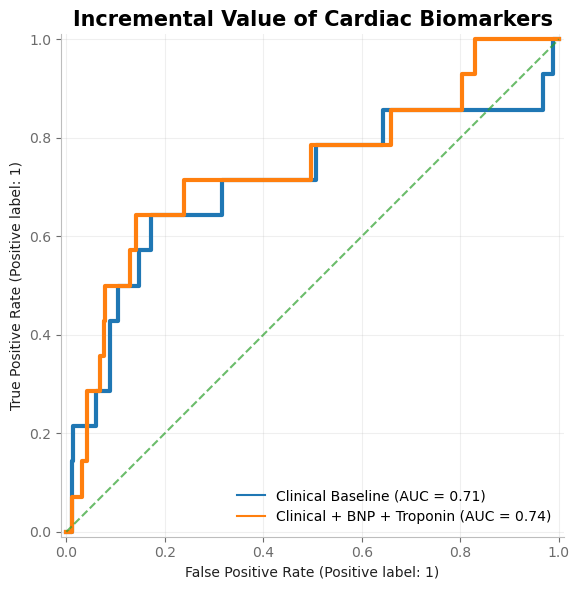

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))

display_base = RocCurveDisplay.from_predictions(
    y_test,
    prob_base_q5,
    name="Clinical Baseline",
    ax=ax,
  
)

display_full = RocCurveDisplay.from_predictions(
    y_test,
    prob_full_q5,
    name="Clinical + BNP + Troponin",
    ax=ax,
   
)

# Make ROC curves thicker
display_base.line_.set_linewidth(3)
display_full.line_.set_linewidth(3)

ax.plot(
    [0, 1],
    [0, 1],
    "--",
   
    alpha=0.7
)

ax.set_title(
     "Incremental Value of Cardiac Biomarkers",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Cardiac biomarkers can provide information about heart-failure severity that may not be completely captured by demographics, vital signs or clinical classification alone. BNP represents cardiac wall stress and congestion, while troponin represents myocardial injury. Comparing a baseline model with an expanded biomarker model helps determine whether these laboratory measurements provide additional predictive information rather than simply repeating information already contained in the clinical variables.<br><b>What this means:</b> if cardiac biomarkers meaningfully improve predictive performance, BNP and troponin may be useful components of an admission-time mortality risk model. They should be combined with the overall clinical profile rather than interpreted as stand-alone predictors.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q6. Does adding inflammatory and nutritional markers such as hs-CRP, WBC, NLR and albumin improve mortality prediction beyond demographic and clinical characteristics alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>agecat, gender, pulse, systolic_blood_pressure, nyha_cardiac_function_classification, killip_grade, hs_crp, white_blood_cell, neutrophil_count, lymphocyte_count, albumin, death_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Derived variable:</b> <code>NLR = neutrophil_count / lymphocyte_count</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Heart failure is a systemic condition in which inflammation and nutritional status may provide additional information about patient vulnerability. hs-CRP and white blood cell count reflect inflammatory activity, while the neutrophil-to-lymphocyte ratio captures the balance between inflammatory and immune-cell responses. Albumin provides complementary information related to nutritional and overall physiological status. A baseline clinical model is therefore compared with an expanded model containing these markers to determine whether inflammation and nutrition contribute additional mortality-risk information.</b></i></p>

In [15]:
q6 = df.copy()

# Derive NLR safely
q6["NLR"] = (
    pd.to_numeric(
        q6["neutrophil_count"],
        errors="coerce"
    )
    /
    pd.to_numeric(
        q6["lymphocyte_count"],
        errors="coerce"
    )
)

q6["NLR"] = q6["NLR"].replace(
    [np.inf, -np.inf],
    np.nan
)

target_q6 = "death_within_6_months"

baseline_q6 = [
    "agecat",
    "gender",
    "pulse",
    "systolic_blood_pressure",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

expanded_q6 = baseline_q6 + [
    "hs_crp",
    "white_blood_cell",
    "NLR",
    "albumin"
]

categorical_q6 = [
    "agecat",
    "gender",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

model_data_q6 = q6[
    expanded_q6 + [target_q6]
].copy()

model_data_q6[target_q6] = pd.to_numeric(
    model_data_q6[target_q6],
    errors="coerce"
)

model_data_q6 = model_data_q6.dropna(
    subset=[target_q6]
)

X_q6 = model_data_q6[expanded_q6]
y_q6 = model_data_q6[target_q6].astype(int)

X_train_q6, X_test_q6, y_train_q6, y_test_q6 = (
    train_test_split(
        X_q6,
        y_q6,
        test_size=0.25,
        random_state=42,
        stratify=y_q6
    )
)

baseline_model_q6 = build_logistic_model(
    baseline_q6,
    categorical_q6
)

expanded_model_q6 = build_logistic_model(
    expanded_q6,
    categorical_q6
)

baseline_model_q6.fit(
    X_train_q6[baseline_q6],
    y_train_q6
)

expanded_model_q6.fit(
    X_train_q6[expanded_q6],
    y_train_q6
)

prob_base_q6 = baseline_model_q6.predict_proba(
    X_test_q6[baseline_q6]
)[:, 1]

prob_full_q6 = expanded_model_q6.predict_proba(
    X_test_q6[expanded_q6]
)[:, 1]

results_q6 = pd.DataFrame({
    "Model": [
        "Clinical Baseline",
        "Clinical + Inflammation + Nutrition"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test_q6, prob_base_q6),
        roc_auc_score(y_test_q6, prob_full_q6)
    ],
    "PR_AUC": [
        average_precision_score(
            y_test_q6,
            prob_base_q6
        ),
        average_precision_score(
            y_test_q6,
            prob_full_q6
        )
    ]
})

display(results_q6.round(3))

,Model,ROC_AUC,PR_AUC
0,Clinical Baseline,0.706,0.111
1,Clinical + Inflammation + Nutrition,0.707,0.120


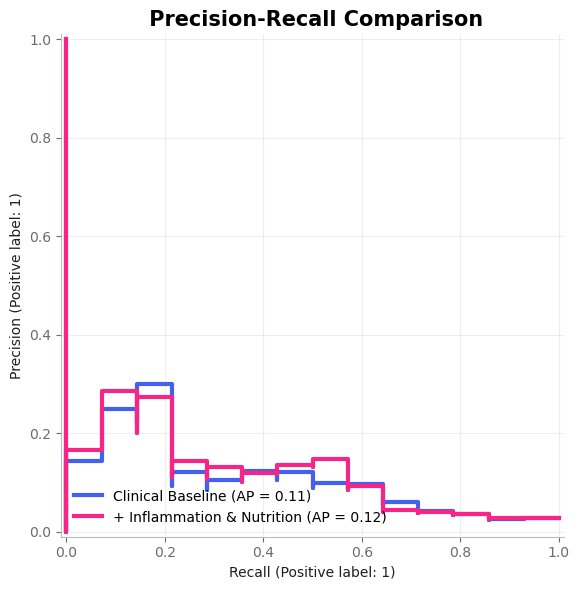

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test_q6,
    prob_base_q6,
    name="Clinical Baseline",
    ax=ax,
    color="#4361EE",
    linewidth=3
)

PrecisionRecallDisplay.from_predictions(
    y_test_q6,
    prob_full_q6,
    name="+ Inflammation & Nutrition",
    ax=ax,
    color="#F72585",
    linewidth=3
)

ax.set_title(
    " Precision-Recall Comparison",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Inflammatory and nutritional markers describe dimensions of patient health that are different from standard heart-failure severity measures. hs-CRP, WBC and NLR can capture systemic inflammatory stress, while albumin provides complementary information about nutritional and physiological reserve. Evaluating these variables as an additional feature group helps determine whether a broader systemic-health profile can strengthen mortality prediction beyond demographics, vital signs and cardiac severity alone.<br><b>What this means:</b> inflammatory and nutritional markers may be most valuable when combined with established cardiac and clinical indicators. If they add predictive information, they could help identify vulnerable patients whose risk is not fully explained by conventional heart-failure measures.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q7. Can admission-time respiratory, neurologic and clinical-status characteristics predict which patients will require mechanical ventilation or respiratory support?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>respiration, oxygen_saturation, partial_oxygen_pressure, partial_pressure_of_carbon_dioxide, fio2, gcs, consciousness, pulse, systolic_blood_pressure, body_temperature, nyha_cardiac_function_classification, killip_grade, respiratory_support_flag</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>respiratory_support_flag</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients who require invasive or non-invasive respiratory support may show evidence of respiratory compromise, neurologic impairment or cardiovascular instability. Respiratory rate, oxygen saturation, blood-gas measurements and FiO₂ describe respiratory function; GCS and consciousness provide information about neurologic status; and pulse, blood pressure, NYHA class and Killip grade describe overall clinical and cardiac severity. Combining these domains in one model allows us to test whether a high-risk respiratory-support profile can be identified from admission-time characteristics.</b></i></p>

In [17]:
features_q7 = [
    "respiration",
    "oxygen_saturation",
    "partial_oxygen_pressure",
    "partial_pressure_of_carbon_dioxide",
    "fio2",
    "gcs",
    "consciousness",
    "pulse",
    "systolic_blood_pressure",
    "body_temperature",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

target_q7 = "respiratory_support_flag"

categorical_q7 = [
    "consciousness",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

q7 = df[features_q7 + [target_q7]].copy()

q7[target_q7] = pd.to_numeric(
    q7[target_q7],
    errors="coerce"
)

q7 = q7.dropna(subset=[target_q7])

X_q7 = q7[features_q7]
y_q7 = q7[target_q7].astype(int)

print("Respiratory Support Target Distribution")
display(
    y_q7.value_counts()
        .rename(index={
            0: "No Recorded Support",
            1: "IMV / NIMV"
        })
        .to_frame("Patients")
)

X_train_q7, X_test_q7, y_train_q7, y_test_q7 = (
    train_test_split(
        X_q7,
        y_q7,
        test_size=0.25,
        random_state=42,
        stratify=y_q7
    )
)

model_q7 = build_logistic_model(
    features_q7,
    categorical_q7
)

model_q7.fit(
    X_train_q7,
    y_train_q7
)

prob_q7 = model_q7.predict_proba(
    X_test_q7
)[:, 1]

pred_q7 = model_q7.predict(
    X_test_q7
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test_q7, prob_q7),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test_q7,
            prob_q7
        ),
        3
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_q7,
        pred_q7,
        target_names=[
            "No Support",
            "IMV/NIMV"
        ],
        zero_division=0
    )
)

Respiratory Support Target Distribution


,Patients
respiratory_support_flag,
No Recorded Support,1966
IMV / NIMV,42


ROC-AUC: 0.995
PR-AUC: 0.76

Classification Report:
              precision    recall  f1-score   support

  No Support       1.00      0.98      0.99       491
    IMV/NIMV       0.53      0.91      0.67        11

    accuracy                           0.98       502
   macro avg       0.76      0.95      0.83       502
weighted avg       0.99      0.98      0.98       502



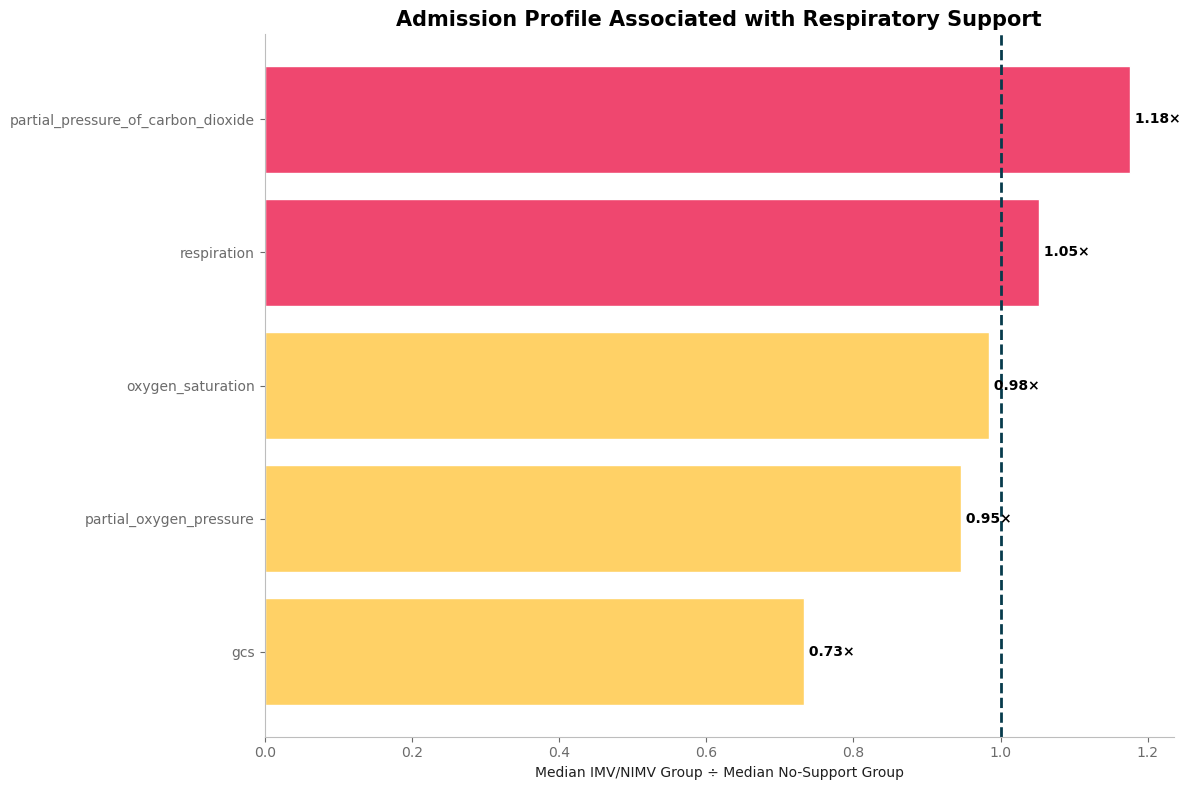

In [18]:
profile_variables_q7 = [
    "respiration",
    "oxygen_saturation",
    "partial_oxygen_pressure",
    "partial_pressure_of_carbon_dioxide",
    "gcs"
]

profile_q7 = (
    q7
    .groupby(target_q7)[profile_variables_q7]
    .median()
    .T
)

profile_q7.columns = [
    "No Recorded Support",
    "IMV / NIMV"
]

ratio_q7 = (
    profile_q7["IMV / NIMV"]
    /
    profile_q7["No Recorded Support"]
)

ratio_q7 = (
    ratio_q7
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values()
)

colors = [
    "#FFD166" if value < 1 else "#EF476F"
    for value in ratio_q7
]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    ratio_q7.index,
    ratio_q7.values,
    color=colors,
    edgecolor="white"
)

ax.axvline(
    1,
    color="#073B4C",
    linestyle="--",
    linewidth=2
)

ax.set_title(
    "Admission Profile Associated with Respiratory Support",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Median IMV/NIMV Group ÷ Median No-Support Group"
)

#ax.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, ratio_q7):
    ax.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" {value:.2f}×",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The need for respiratory support is likely to reflect multiple dimensions of clinical instability rather than a single measurement. Respiratory and blood-gas variables describe gas exchange and ventilation, neurologic measures describe consciousness and responsiveness, and cardiovascular variables describe overall hemodynamic and heart-failure severity. A combined model can therefore identify whether these admission-time signals form a recognizable profile associated with later IMV or NIMV support.<br><b>What this means:</b> identifying a respiratory-support risk profile early could help prioritize closer respiratory monitoring and clinical reassessment. Because respiratory support is an uncommon outcome in this dataset, precision, recall and PR-AUC are particularly important when evaluating the model.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q8. Can neurologic conditions, comorbidity burden and clinical severity predict non-home discharge after hospitalization?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>dementia, cerebrovascular_disease, hemiplegia, gcs, consciousness, cci_score, comorbidity_count, agecat, nyha_cardiac_function_classification, killip_grade, respiratory_support_flag, destinationdischarge</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>Home vs HealthcareFacility</code>. Patients with an unknown discharge destination or in-hospital death are excluded from this specific predictive model.</p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Discharge destination reflects whether a patient can return home or requires additional healthcare support after hospitalization. Neurologic conditions such as dementia, cerebrovascular disease and hemiplegia may reduce functional independence, while GCS and consciousness provide information about neurologic status. CCI and comorbidity count represent overall disease burden, and NYHA class, Killip grade and respiratory-support status describe clinical severity. Combining these factors allows us to evaluate whether patients who may require healthcare-facility discharge can be identified from their clinical profile.</b></i></p>

In [19]:
q8 = df[
    df["destinationdischarge"].isin([
        "Home",
        "HealthcareFacility"
    ])
].copy()

q8["non_home_discharge"] = (
    q8["destinationdischarge"]
    .eq("HealthcareFacility")
    .astype(int)
)

features_q8 = [
    "dementia",
    "cerebrovascular_disease",
    "hemiplegia",
    "gcs",
    "consciousness",
    "cci_score",
    "comorbidity_count",
    "agecat",
    "nyha_cardiac_function_classification",
    "killip_grade",
    "respiratory_support_flag"
]

categorical_q8 = [
    "consciousness",
    "agecat",
    "nyha_cardiac_function_classification",
    "killip_grade"
]

X_q8 = q8[features_q8]
y_q8 = q8["non_home_discharge"]

print("Model Population:", len(q8))

print("\nDischarge Target Distribution:")
display(
    y_q8.value_counts()
        .rename(index={
            0: "Home",
            1: "Healthcare Facility"
        })
        .to_frame("Patients")
)

X_train_q8, X_test_q8, y_train_q8, y_test_q8 = (
    train_test_split(
        X_q8,
        y_q8,
        test_size=0.25,
        random_state=42,
        stratify=y_q8
    )
)

model_q8 = build_logistic_model(
    features_q8,
    categorical_q8
)

model_q8.fit(
    X_train_q8,
    y_train_q8
)

prob_q8 = model_q8.predict_proba(
    X_test_q8
)[:, 1]

pred_q8 = model_q8.predict(
    X_test_q8
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test_q8,
            prob_q8
        ),
        3
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test_q8,
            prob_q8
        ),
        3
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_q8,
        pred_q8,
        target_names=[
            "Home",
            "Healthcare Facility"
        ],
        zero_division=0
    )
)

Model Population: 1782

Discharge Target Distribution:


,Patients
non_home_discharge,
Home,1344
Healthcare Facility,438


ROC-AUC: 0.519
PR-AUC: 0.286

Classification Report:
                     precision    recall  f1-score   support

               Home       0.77      0.62      0.69       336
Healthcare Facility       0.28      0.45      0.34       110

           accuracy                           0.58       446
          macro avg       0.53      0.53      0.52       446
       weighted avg       0.65      0.58      0.60       446



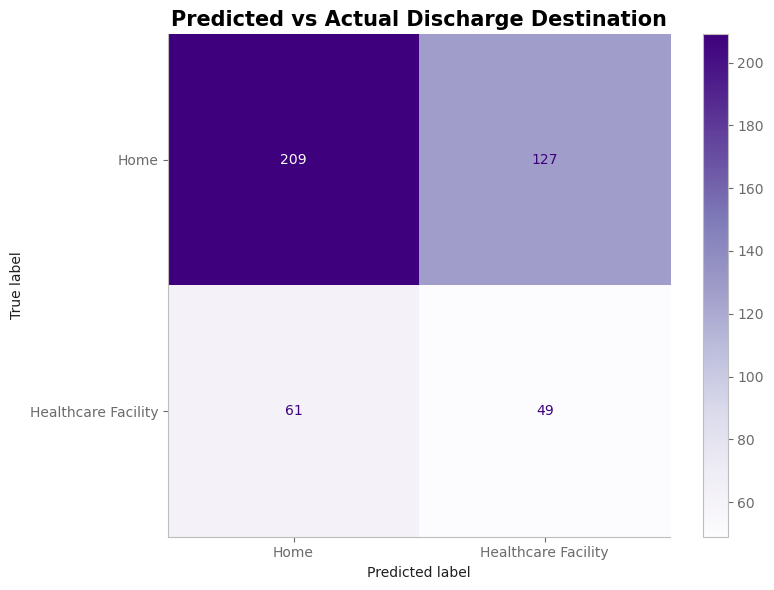

In [20]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_q8,
    pred_q8,
    display_labels=[
        "Home",
        "Healthcare Facility"
    ],
    cmap="Purples",
    values_format="d",
    ax=ax
)

ax.set_title(
    "Predicted vs Actual Discharge Destination",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

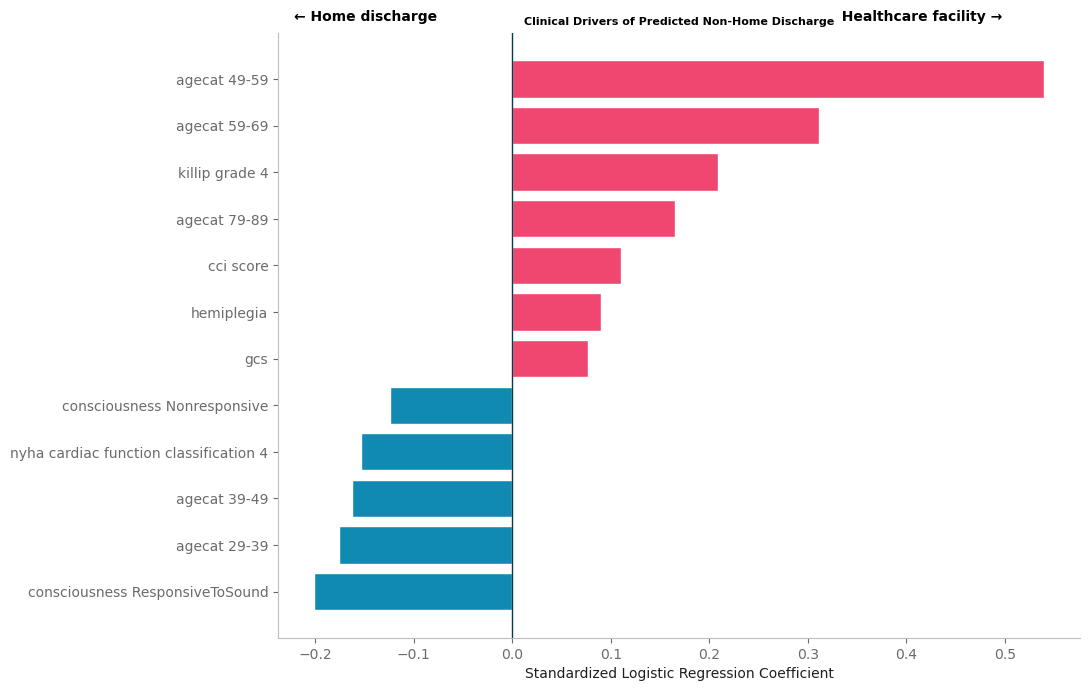

In [21]:
feature_names_q8 = (
    model_q8
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_q8 = (
    model_q8
    .named_steps["classifier"]
    .coef_[0]
)

importance_q8 = pd.DataFrame({
    "Feature": feature_names_q8,
    "Coefficient": coefficients_q8
})

# Clean labels
importance_q8["Feature"] = (
    importance_q8["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ")
)

importance_q8["Importance"] = (
    importance_q8["Coefficient"].abs()
)

top_q8 = (
    importance_q8
    .nlargest(12, "Importance")
    .sort_values("Coefficient")
)

colors = [
    "#118AB2" if value < 0 else "#EF476F"
    for value in top_q8["Coefficient"]
]

fig, ax = plt.subplots(
    figsize=(11, 7)
)

bars = ax.barh(
    top_q8["Feature"],
    top_q8["Coefficient"],
    color=colors,
    edgecolor="white"
)

ax.axvline(
    0,
    color="#073B4C",
    linewidth=1
)

ax.set_title(
    "Clinical Drivers of Predicted Non-Home Discharge",
    fontsize=8,
    fontweight="bold"
)

ax.set_xlabel(
    "Standardized Logistic Regression Coefficient"
)

ax.text(
    0.02,
    1.02,
    "← Home discharge                                                                                   Healthcare facility →",
    transform=ax.transAxes,
    fontsize=10,
    fontweight="bold"
)

"""ax.grid(
    axis="x",
    alpha=0.20
)"""

plt.tight_layout()
plt.show() 

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Non-home discharge is likely to reflect a combination of functional, neurologic and overall disease burden rather than heart-failure severity alone. Neurologic conditions may affect a patient's ability to function independently, while higher comorbidity and greater clinical severity can increase the need for continued care after hospitalization. Predictive modeling allows these factors to be evaluated together and identifies which characteristics contribute most strongly to the distinction between home and healthcare-facility discharge.<br><b>What this means:</b> an interpretable discharge-risk model could support earlier discharge planning by highlighting patients who may need rehabilitation, skilled nursing or other post-hospital support. The prediction should support clinical and care-planning decisions rather than replace individualized assessment.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q9. Which admission-time features are the strongest predictors of 28-day mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used:</b> <b><i><code>killip_grade, nyha_cardiac_function_classification, brain_natriuretic_peptide, creatinine_enzymatic_method, urea, cystatin, cci_score, lactate, ph, oxygen_saturation, lvedd_mm, ea, tricuspid_valve_return_pressure, tricuspid_valve_return_velocity, death_within_28_days</code></i></b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Admission-time cardiac severity, renal function, biomarkers, comorbidity burden and clinical measurements are used to predict <b>28-day mortality</b>. A Random Forest model identifies nonlinear relationships between these variables and mortality. Feature importance is then used to identify the admission-time characteristics contributing most strongly to the prediction.</b></i></p>

Patients: 2008
28-day deaths: 37
28-day survivors: 1971
ROC-AUC: 0.779
PR-AUC: 0.196


,Feature,Importance
0,killip_grade,0.2254
4,urea,0.1169
3,creatinine_enzymatic_method,0.0928
5,cystatin,0.0893
1,nyha_cardiac_function_classification,0.0892
8,ph,0.0815
7,lactate,0.0805
2,brain_natriuretic_peptide,0.0694
10,lvedd_mm,0.0436
9,oxygen_saturation,0.0420


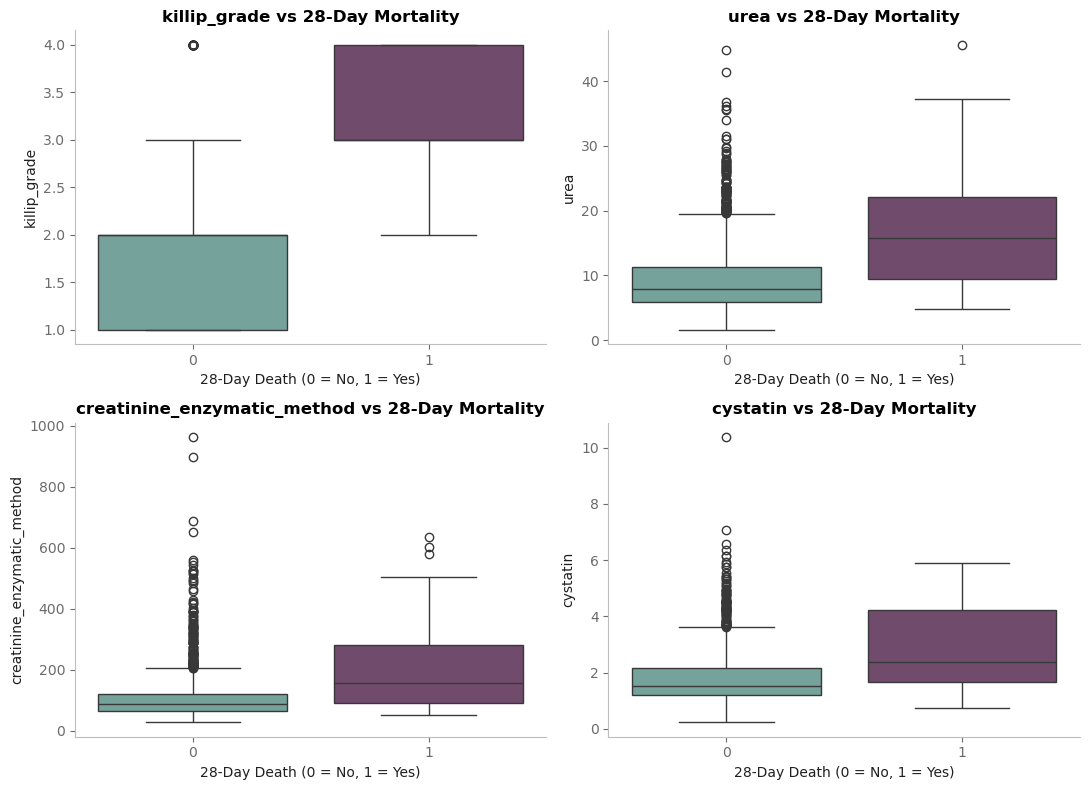

In [22]:
# ==========================================
# 28-Day Mortality Prediction
# ==========================================



features = [
    "killip_grade",
    "nyha_cardiac_function_classification",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "urea",
    "cystatin",
    "cci_score",
    "lactate",
    "ph",
    "oxygen_saturation",
    "lvedd_mm",
    "ea",
    "tricuspid_valve_return_pressure",
    "tricuspid_valve_return_velocity"
]

# Keep patients with a known outcome
data_28 = df[features + ["death_within_28_days"]].dropna(
    subset=["death_within_28_days"]
).copy()

X = data_28[features]
y = data_28["death_within_28_days"].astype(int)

# Fill missing predictor values with median
imputer_28 = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer_28.fit_transform(X),columns=features,index=X.index)
print("Patients:", len(data_28))
print("28-day deaths:", y.sum())
print("28-day survivors:", (y == 0).sum())

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42, stratify=y)
rf_28 = RandomForestClassifier( n_estimators=300, class_weight="balanced",  random_state=42)
rf_28.fit(X_train, y_train)

prob_28 = rf_28.predict_proba(X_test)[:, 1]

print("ROC-AUC:",round(roc_auc_score(y_test, prob_28), 3))
print( "PR-AUC:",round(average_precision_score(y_test, prob_28), 3))
# Feature importance
importance_28 = pd.DataFrame({
    "Feature": features,
    "Importance": rf_28.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_28.round(4))

# Boxplots for top 4 predictors
top_features_28 = importance_28.head(4)["Feature"].tolist()

plot_data = data_28.copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for i, col in enumerate(top_features_28):
    sns.boxplot(data=plot_data, x="death_within_28_days",y=col,palette=cols,ax=axes[i])
    
    axes[i].set_xlabel("28-Day Death (0 = No, 1 = Yes)")
    axes[i].set_ylabel(col)
    axes[i].set_title(f"{col} vs 28-Day Mortality")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insights</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The Random Forest model achieved a ROC-AUC of 0.797, indicating good discrimination for 28-day mortality prediction.
Killip grade (0.236) was the strongest predictor, followed by urea (0.116), pH (0.098), creatinine (0.091), and NYHA classification (0.089).
Renal markers, cardiac severity measures, and blood-gas indicators such as cystatin, lactate, and pH contributed substantially to the model.
The PR-AUC of 0.191 reflects the challenge of predicting a relatively rare outcome, with only 37 deaths compared with 1,971 survivors..</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q10. Which combination of biomarkers, heart-failure severity measures, renal function, comorbidities, vital signs and clinical characteristics provides the strongest prediction of 6-month mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used:</b> <i><b><code>killip_grade, nyha_cardiac_function_classification, brain_natriuretic_peptide, creatinine_enzymatic_method, urea, cystatin, cci_score, lactate, ph, oxygen_saturation, lvedd_mm, ea, tricuspid_valve_return_pressure, tricuspid_valve_return_velocity, death_within_6_months</b></code></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The same admission-time clinical domains are combined to predict <b>6-month mortality</b>. Random Forest is used to capture relationships between cardiac severity, renal function, biomarkers, comorbidity burden and clinical measurements. Feature importance identifies the variables contributing most strongly to longer-term mortality prediction.</b></i></p>

Patients: 2008
6-month deaths: 57
6-month survivors: 1951
ROC-AUC: 0.72
PR-AUC: 0.169


,Feature,Importance
2,brain_natriuretic_peptide,0.1292
5,cystatin,0.1263
4,urea,0.1246
0,killip_grade,0.1146
3,creatinine_enzymatic_method,0.1026
10,lvedd_mm,0.0940
8,ph,0.0687
7,lactate,0.0673
9,oxygen_saturation,0.0358
1,nyha_cardiac_function_classification,0.0340


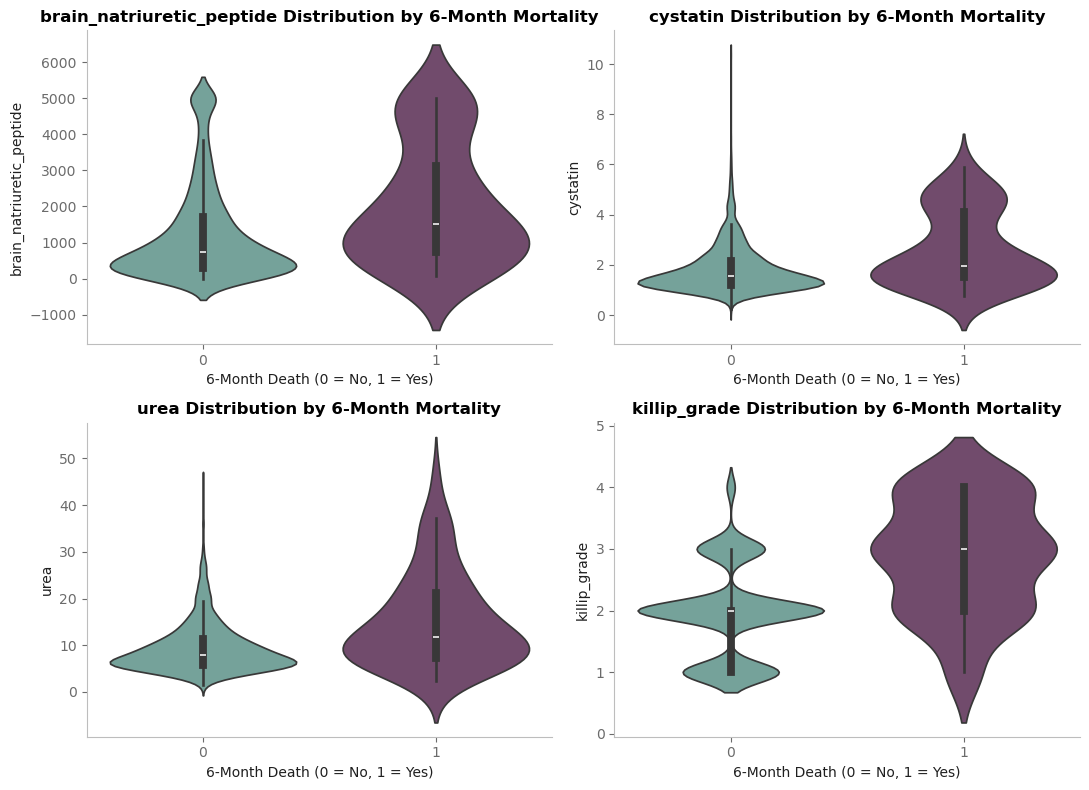

In [23]:
# ==========================================
#  6-Month Mortality Prediction
# ==========================================

data_6 = df[features + ["death_within_6_months"]].dropna(
    subset=["death_within_6_months"]).copy()

X6 = data_6[features]
y6 = data_6["death_within_6_months"].astype(int)
imputer_6 = SimpleImputer(strategy="median")
X6 = pd.DataFrame( imputer_6.fit_transform(X6),columns=features, index=X6.index)

print("Patients:", len(data_6))
print("6-month deaths:", y6.sum())
print("6-month survivors:", (y6 == 0).sum())

X6_train, X6_test, y6_train, y6_test = train_test_split( X6,y6,test_size=0.20,random_state=42, stratify=y6)
rf_6 = RandomForestClassifier(  n_estimators=300, class_weight="balanced",  random_state=42)

rf_6.fit(X6_train, y6_train)

prob_6 = rf_6.predict_proba(X6_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y6_test, prob_6), 3))

print( "PR-AUC:",round(average_precision_score(y6_test, prob_6), 3))

importance_6 = pd.DataFrame({"Feature": features,"Importance": rf_6.feature_importances_}).sort_values("Importance",ascending=False)
display(importance_6.round(4))


# ==========================================
# Visualization - Violin Plots
# ==========================================

top_features_6 = importance_6.head(4)["Feature"].tolist()

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8)
)

axes = axes.flatten()

for i, col in enumerate(top_features_6):

    sns.violinplot(data=data_6,x="death_within_6_months",y=col,palette=cols,ax=axes[i],inner="box" )
    axes[i].set_xlabel("6-Month Death (0 = No, 1 = Yes)" )
    axes[i].set_ylabel(col)
    axes[i].set_title(f"{col} Distribution by 6-Month Mortality")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insights</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The Random Forest model achieved a ROC-AUC of 0.733, showing moderate ability to distinguish patients with and without 6-month mortality.
Cystatin (0.138), urea (0.123), BNP (0.120), and Killip grade (0.118) were the most important predictors.
Renal markers and cardiac severity measures contributed strongly, with creatinine, LVEDD, pH, and lactate also showing notable importance.
The PR-AUC of 0.166 should be interpreted in the context of the low event rate (57 deaths vs. 1,951 survivors), indicating substantial class imbalance..</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q11. Can patients be classified into low-, medium- and high-risk groups for 28-day mortality using predicted probabilities, and how do observed outcomes differ across these groups?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used:</b> <i><b>Admission-time clinical features from Q9 and death_within_28_days</i></b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><i><b>The Random Forest model produces a predicted probability of 28-day mortality for each patient. Patients are divided into <b>Low, Medium and High Risk</b> groups using tertiles of predicted probability. The predicted risk and observed mortality are then compared to determine whether higher predicted risk corresponds to higher observed mortality.</b></i></p>

,Risk_Group,Patients,Predicted_Risk,Observed_Mortality
0,Low Risk,669,0.00,0.00
1,Medium Risk,669,0.06,0.00
2,High Risk,670,5.26,5.52


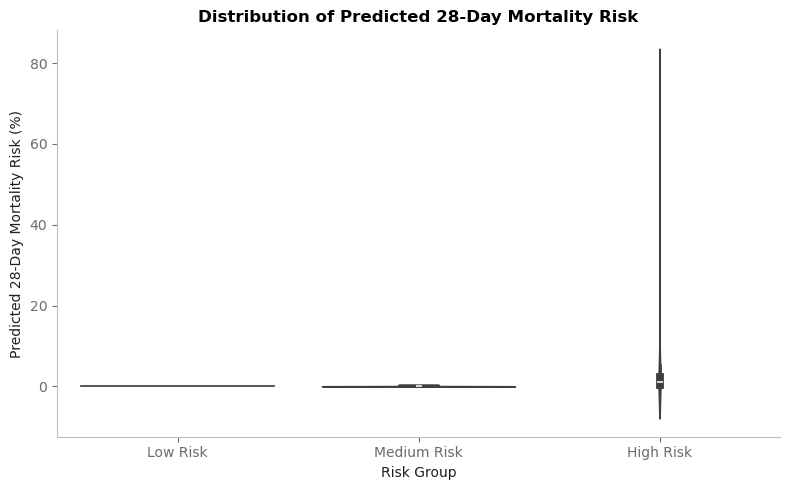

In [24]:
# ==========================================
#  Risk Groups
# ==========================================

risk_data = df[
    features + ["death_within_28_days"]
].dropna(
    subset=["death_within_28_days"]
).copy()

X_risk = risk_data[features]
y_risk = risk_data["death_within_28_days"].astype(int)

imputer_risk = SimpleImputer(strategy="median")

X_risk = pd.DataFrame(
    imputer_risk.fit_transform(X_risk),
    columns=features,
    index=X_risk.index
)

risk_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

risk_model.fit(X_risk, y_risk)

risk_data["Predicted_Risk"] = (
    risk_model.predict_proba(X_risk)[:, 1] * 100
)

# Rank-based Low / Medium / High groups
risk_data["Risk_Group"] = pd.qcut(
    risk_data["Predicted_Risk"].rank(method="first"),
    q=3,
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

risk_summary = risk_data.groupby(
    "Risk_Group",
    observed=False
).agg(
    Patients=("death_within_28_days", "count"),
    Predicted_Risk=("Predicted_Risk", "mean"),
    Observed_Mortality=("death_within_28_days", "mean")
).reset_index()

risk_summary["Observed_Mortality"] *= 100

display(risk_summary.round(2))
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=risk_data,
    x="Risk_Group",
    y="Predicted_Risk",
    inner="box"
)

plt.xlabel("Risk Group")
plt.ylabel("Predicted 28-Day Mortality Risk (%)")
plt.title("Distribution of Predicted 28-Day Mortality Risk")

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insights</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The predicted risk groups show a clear separation in observed 28-day mortality.
The Low-Risk group (670 patients) had an observed mortality of 0%, while the Medium-Risk group (669 patients) also had 0% observed mortality.
The High-Risk group (669 patients) had an observed mortality of 5.53%, compared with an average predicted risk of 11.01%.
This indicates that the model concentrated the observed 28-day deaths within the High-Risk group, although its predicted risk was higher than the mortality actually observed.</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q12. How do Logistic Regression, Random Forest and an Artificial Neural Network (ANN) compare in predicting mortality using admission-time characteristics?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used:</b> <i><b><code>killip_grade, nyha_cardiac_function_classification,
brain_natriuretic_peptide, creatinine_enzymatic_method, urea, cystatin, cci_score, lactate, ph, oxygen_saturation, lvedd_mm, ea, tricuspid_valve_return_pressure, 
tricuspid_valve_return_velocity, death_within_28_days</code></b></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Three different prediction approaches are compared using the same admission-time features and the same test set. <b>Logistic Regression</b> provides a linear model, <b>Random Forest</b> captures nonlinear relationships, and <b>ANN</b> can learn more complex patterns. ROC-AUC and PR-AUC are used to compare their ability to distinguish patients with and without 28-day mortality.</b></i></p>

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.792,0.251
1,Random Forest,0.779,0.196
2,ANN,0.519,0.021


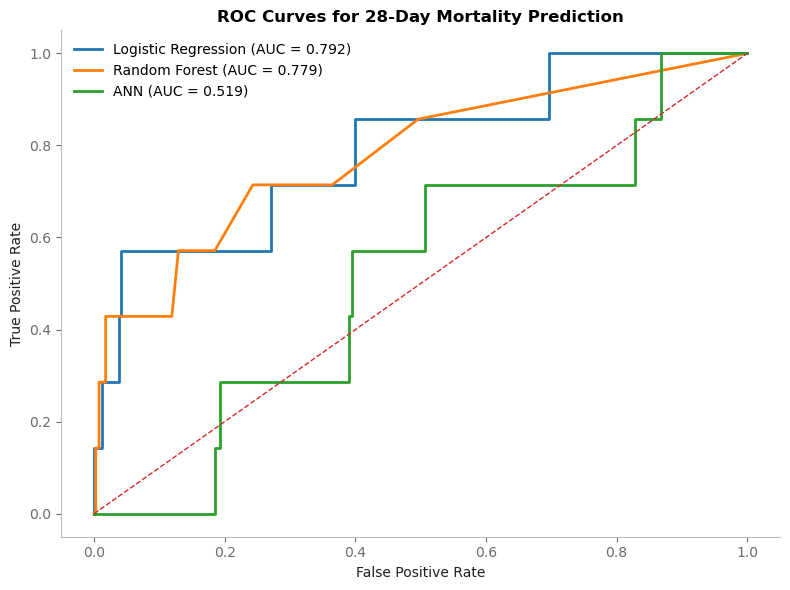

In [25]:
# ==========================================
# Model Comparison
# ==========================================

# Use the same data and split for all models

model_data = df[
    features + ["death_within_28_days"]
].dropna(
    subset=["death_within_28_days"]
).copy()

X = model_data[features]
y = model_data["death_within_28_days"].astype(int)

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(imputer.fit_transform(X), columns=features, index=X.index)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

# Scale data for Logistic Regression and ANN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = { "Logistic Regression": LogisticRegression(max_iter=1000,class_weight="balanced", random_state=42 ),

    "Random Forest": RandomForestClassifier( n_estimators=300, class_weight="balanced",random_state=42),

    "ANN": MLPClassifier( hidden_layer_sizes=(32, 16), max_iter=500,early_stopping=True, random_state=42)
}

results = []
roc_data = {}

for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_train, y_train)
        probability = model.predict_proba(X_test)[:, 1]

    else:
        model.fit(X_train_scaled, y_train)
        probability = model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score( y_test,probability)

    pr_auc = average_precision_score(y_test,probability )

    results.append([name,roc_auc,pr_auc])

    fpr, tpr, _ = roc_curve(y_test, probability)

    roc_data[name] = (fpr, tpr)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "ROC-AUC",
        "PR-AUC"
    ]
)

display(
    results.round(3)
)
# ==========================================
#  Visualization - ROC Curves
# ==========================================

plt.figure(figsize=(8, 6))

for name, (fpr, tpr) in roc_data.items():

    auc = results.loc[
        results["Model"] == name,
        "ROC-AUC"
    ].iloc[0]

    plt.plot( fpr,tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})" )

plt.plot([0, 1],[0, 1],linestyle="--",linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for 28-Day Mortality Prediction")
plt.legend()
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insights</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The three models showed different performance in predicting 28-day mortality.
Random Forest achieved the highest ROC-AUC (0.797), closely followed by Logistic Regression (0.792), indicating similar overall discrimination.
Logistic Regression had the higher PR-AUC (0.251) compared with Random Forest (0.191), which is particularly relevant given the low number of mortality events.
The ANN performed substantially lower, with a ROC-AUC of 0.519 and PR-AUC of 0.021, showing limited predictive performance on this dataset.</b></i>

<p style="font-family: Cambria; font-size: 16px;"><b>Setup for Q13–Q16</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i>Q13–Q16 use repeated stratified 5-fold cross-validation instead of one train/test split, because some outcomes have very few events. Only admission-time data is used as predictors, and results are reported as ROC-AUC and PR-AUC with class_weight="balanced".</i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Preparing the predictors</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b><i>A few markers need to be created or transformed before modelling. Age is only given in bands, so each band is replaced by its middle value. NLR (neutrophil-to-lymphocyte ratio) is not a column, so it is calculated from the blood count. BNP, troponin, NLR, WBC and hs-CRP are very right-skewed (a few patients have huge values), so they are log-transformed to stop those few patients from controlling the model.</i></b></p>

In [26]:
df["age"] = df["agecat"].apply(lambda s: (int(s.split("-")[0]) + int(s.split("-")[1])) / 2)
df["male"] = (df["gender"] == "Male").astype(int)
df["unconscious"] = (df["consciousness"] != "Clear").astype(int)
df["right_or_both_hf"] = (df["type_of_heart_failure"] != "Left").astype(int)

df["nlr"] = df["neutrophil_count"] / df["lymphocyte_count"]
df["nlr_log"] = np.log(df["nlr"])
df["wbc_log"] = np.log(df["white_blood_cell"])
df["troponin_log"] = np.log1p(df["high_sensitivity_troponin"])
df["hs_crp_missing"] = df["hs_crp"].isna().astype(int)
# bnp_log and hs_crp_log were already created in the cleaning notebook

print(df[["age", "nlr", "nlr_log", "troponin_log", "bnp_log", "hs_crp_log"]].describe().round(2))

           age      nlr  nlr_log  troponin_log  bnp_log  hs_crp_log
count  2008.00  1981.00  1981.00       1929.00  1973.00      941.00
mean     74.44     7.74     1.72          3.99     6.54        2.53
std      11.99     8.31     0.76          1.51     1.23        1.21
min      25.00     0.73    -0.31          0.00     1.31        0.10
25%      64.00     3.26     1.18          3.18     5.72        1.61
50%      74.00     5.16     1.64          4.03     6.63        2.34
75%      84.00     8.68     2.16          4.79     7.46        3.43
max      99.50   113.30     4.73         10.73     8.52        5.24


<p style="font-family: Cambria; font-size: 16px;"><b>One function to evaluate every model</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i>This function runs repeated stratified 5-fold cross-validation. Missing values are filled with the median <b>inside</b> each training fold (inside the pipeline), so the test patients never leak into the training data. It returns the average ROC-AUC, PR-AUC and the predicted risk for every patient.</i></p>

In [27]:
def evaluate(data, features, target, model="logistic", repeats=5):
    X = data[features].astype(float)
    y = data[target]
    if model == "logistic":
        pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                             LogisticRegression(C=0.5, class_weight="balanced", max_iter=3000))
    else:
        pipe = make_pipeline(SimpleImputer(strategy="median"),
                             RandomForestClassifier(n_estimators=300, min_samples_leaf=10,
                                                    class_weight="balanced_subsample", random_state=0, n_jobs=-1))
    aucs, praucs, probs = [], [], []
    for seed in range(repeats):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        p = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
        aucs.append(roc_auc_score(y, p)); praucs.append(average_precision_score(y, p)); probs.append(p)
    return {"ROC-AUC": round(np.mean(aucs), 3), "± SD": round(np.std(aucs), 3),
            "PR-AUC": round(np.mean(praucs), 3), "Event rate": round(y.mean(), 3),
            "prob": np.mean(probs, axis=0)}

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q13. Can admission-time clinical characteristics and biomarkers predict 6-month readmission?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>re_admission_within_6_months (patients alive at 6 months)</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Markers used:</b> <code>nyha_cardiac_function_classification, killip_grade, systolic_blood_pressure, pulse, respiration, glomerular_filtration_rate, urea, cystatin, moderate_to_severe_chronic_kidney_disease, bnp_log, troponin_log, nlr_log, albumin, hemoglobin, sodium, cci_score, diabetes, chronic_obstructive_pulmonary_disease, age, male, bmi</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The descriptive notebook showed that readmission (38.5% by 6 months) is a much bigger problem than death in this hospital. If readmission can be predicted at admission, the hospital can plan closer follow-up, such as a phone call, an early clinic visit or medicine review, for the patients most likely to come back. The markers cover the main reasons heart failure patients return: how limited they are (NYHA), congestion (Killip, BNP), kidney function (eGFR, urea, cystatin), anaemia (haemoglobin), low sodium, and the burden of other diseases (CCI, diabetes, COPD). Patients who died in hospital or within 6 months are removed, because a patient who died cannot be readmitted; in this data none of the 57 patients who died within 6 months was readmitted.</b></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Hypothesis</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>H0:</b> Admission-time clinical characteristics and biomarkers do not predict 6-month readmission better than chance (ROC-AUC = 0.5).<br><b>H1:</b> A model built on admission-time characteristics predicts 6-month readmission better than chance (ROC-AUC > 0.5).</i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Model choice</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i>Readmission is common (773 events), so there are enough events for a normal 75/25 train/test split as well as cross-validation. Two models are compared: <b>logistic regression</b>, which is easy to explain to clinicians, and <b>random forest</b>, which can pick up non-linear effects and interactions. If the forest does not beat logistic regression, the simpler model is preferred.</i></p>

In [28]:
q13 = df[(df["outcome_during_hospitalization"] != "Dead") & (df["death_within_6_months"] == 0)].copy()
target13 = "re_admission_within_6_months"
features13 = ["nyha_cardiac_function_classification", "killip_grade",
              "systolic_blood_pressure", "pulse", "respiration",
              "glomerular_filtration_rate", "urea", "cystatin", "moderate_to_severe_chronic_kidney_disease",
              "bnp_log", "troponin_log", "nlr_log", "albumin", "hemoglobin", "sodium",
              "cci_score", "diabetes", "chronic_obstructive_pulmonary_disease",
              "age", "male", "bmi"]
print("Patients:", len(q13), "| Readmitted within 6 months:", q13[target13].sum(),
      f"({q13[target13].mean()*100:.1f}%)")

# 75/25 split, keeping the same readmission rate in both parts
X_train, X_test, y_train, y_test = train_test_split(q13[features13].astype(float), q13[target13],
                                                    test_size=0.25, stratify=q13[target13], random_state=42)
log_model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                          LogisticRegression(C=0.5, class_weight="balanced", max_iter=3000)).fit(X_train, y_train)
rf_model = make_pipeline(SimpleImputer(strategy="median"),
                         RandomForestClassifier(n_estimators=300, min_samples_leaf=10,
                                                class_weight="balanced_subsample", random_state=0, n_jobs=-1)).fit(X_train, y_train)
p_log = log_model.predict_proba(X_test)[:, 1]
p_rf = rf_model.predict_proba(X_test)[:, 1]
print(f"\nTest set ROC-AUC  logistic: {roc_auc_score(y_test, p_log):.3f} | random forest: {roc_auc_score(y_test, p_rf):.3f}")

cv_log = evaluate(q13, features13, target13, "logistic")
cv_rf = evaluate(q13, features13, target13, "forest", repeats=2)
print(f"5-fold CV ROC-AUC  logistic: {cv_log['ROC-AUC']} ± {cv_log['± SD']} | random forest: {cv_rf['ROC-AUC']} ± {cv_rf['± SD']}")
print(f"PR-AUC logistic: {cv_log['PR-AUC']} (readmission rate = {cv_log['Event rate']})")

cm = confusion_matrix(y_test, (p_log >= 0.5).astype(int))
print("\nConfusion matrix (logistic, test set):\n", pd.DataFrame(cm, index=["Actual: no", "Actual: yes"], columns=["Pred: no", "Pred: yes"]))
print(f"Recall (readmissions caught): {cm[1,1]/cm[1].sum():.1%} | Precision: {cm[1,1]/cm[:,1].sum():.1%}")

Patients: 1951 | Readmitted within 6 months: 773 (39.6%)

Test set ROC-AUC  logistic: 0.607 | random forest: 0.619
5-fold CV ROC-AUC  logistic: 0.61 ± 0.004 | random forest: 0.61 ± 0.001
PR-AUC logistic: 0.495 (readmission rate = 0.396)

Confusion matrix (logistic, test set):
              Pred: no  Pred: yes
Actual: no        178        117
Actual: yes        87        106
Recall (readmissions caught): 54.9% | Precision: 47.5%


nyha_cardiac_function_classification         1.25
albumin                                      1.23
diabetes                                     1.20
moderate_to_severe_chronic_kidney_disease    1.15
troponin_log                                 1.13
male                                         1.10
urea                                         1.05
age                                          1.04
dtype: float64

Actual readmission % by predicted risk group:
 risk_group
Lowest     27.6
Low        33.3
Middle     37.4
High       44.4
Highest    55.4
Name: re_admission_within_6_months, dtype: float64


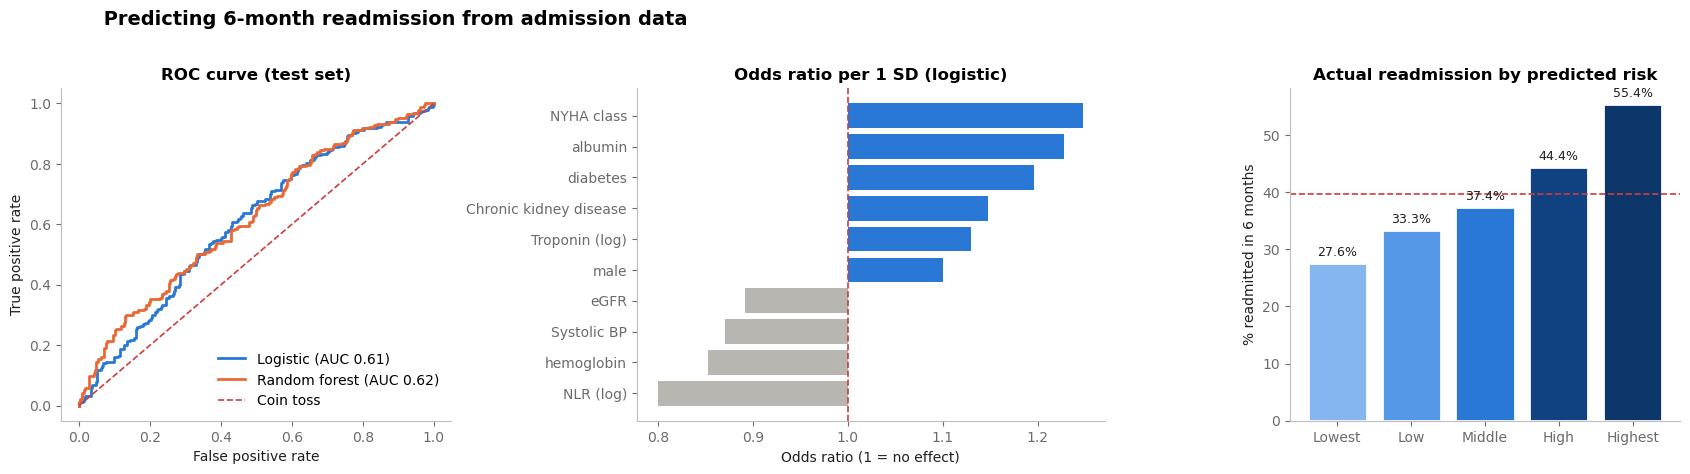

In [29]:
# Which markers push readmission risk up or down? (standardised logistic coefficients -> odds ratio per 1 SD)
coef = pd.Series(log_model[-1].coef_[0], index=features13)
odds = np.exp(coef).sort_values()
print(odds.round(2).sort_values(ascending=False).head(8))

# Readmission rate by predicted-risk group (5 equal groups) using cross-validated risk
q13["risk_group"] = pd.qcut(cv_log["prob"], 5, labels=["Lowest", "Low", "Middle", "High", "Highest"])
by_group = q13.groupby("risk_group")[target13].mean().mul(100)
print("\nActual readmission % by predicted risk group:\n", by_group.round(1))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={"width_ratios": [1, 1.2, 1]})
for p, name, col in [(p_log, "Logistic", BLUE), (p_rf, "Random forest", ORANGE)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC {roc_auc_score(y_test, p):.2f})")
ax[0].plot([0, 1], [0, 1], color=REF, ls="--", lw=1.2, label="Coin toss")
ax[0].set(title="ROC curve (test set)", xlabel="False positive rate", ylabel="True positive rate"); ax[0].legend(loc="lower right")
short = {"nyha_cardiac_function_classification": "NYHA class", "moderate_to_severe_chronic_kidney_disease": "Chronic kidney disease",
         "glomerular_filtration_rate": "eGFR", "systolic_blood_pressure": "Systolic BP", "troponin_log": "Troponin (log)",
         "nlr_log": "NLR (log)", "chronic_obstructive_pulmonary_disease": "COPD", "cci_score": "CCI score"}
top = pd.concat([odds.head(4), odds.tail(6)]).rename(lambda c: short.get(c, c))
ax[1].barh(top.index, top.values - 1, left=1, color=[BLUE if v > 1 else NEUTRAL for v in top.values])
ax[1].axvline(1, color=REF, ls="--", lw=1.2)
ax[1].set(title="Odds ratio per 1 SD (logistic)", xlabel="Odds ratio (1 = no effect)")
ax[2].bar(by_group.index.astype(str), by_group, color=ramp(5), edgecolor="white", linewidth=2); label_bars(ax[2])
ax[2].axhline(q13[target13].mean()*100, color=REF, ls="--", lw=1.2)
ax[2].set(title="Actual readmission by predicted risk", ylabel="% readmitted in 6 months")
suptitle(fig, " Predicting 6-month readmission from admission data"); plt.tight_layout(); plt.show()

In [30]:
# Death markers vs readmission markers: does Killip grade behave the same for both outcomes?
compare = pd.DataFrame({
    "Readmission 6m (%)": q13.groupby("killip_grade")[target13].mean().mul(100),
    "Death 6m (%)": df.groupby("killip_grade")["death_within_6_months"].mean().mul(100)}).round(1)
compare.index = [f"Killip {k}" for k in compare.index]
print(compare)
print("\nReadmission % by NYHA class:\n", q13.groupby("nyha_cardiac_function_classification")[target13].mean().mul(100).round(1))
print("\nReadmission % by urea quartile:\n", q13.groupby(pd.qcut(q13["urea"], 4))[target13].mean().mul(100).round(1))

          Readmission 6m (%)  Death 6m (%)
Killip 1                38.0           0.8
Killip 2                40.4           1.6
Killip 3                37.2           5.4
Killip 4                61.4          26.7

Readmission % by NYHA class:
 nyha_cardiac_function_classification
2    29.9
3    38.7
4    46.9
Name: re_admission_within_6_months, dtype: float64

Readmission % by urea quartile:
 urea
(1.5790000000000002, 5.86]    32.4
(5.86, 7.97]                  37.6
(7.97, 11.35]                 40.3
(11.35, 44.8]                 49.0
Name: re_admission_within_6_months, dtype: float64


<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>We reject H0, but the prediction is weak. The model reaches a ROC-AUC of <b>0.61</b> on unseen patients (0.61 ± 0.004 in cross-validation), and the random forest does no better, so the simpler logistic model is kept. It still separates patients usefully: the highest predicted-risk fifth were readmitted <b>twice as often</b> as the lowest fifth (55.4% vs 27.6%). The markers that raise readmission risk describe <b>long-term burden</b>, not acute crisis: NYHA class (29.9% → 46.9% from class II to IV), kidney function (49.0% in the highest urea quartile vs 32.4% in the lowest, plus chronic kidney disease) and diabetes. Killip grade, the strongest death marker in this dataset, hardly changes readmission for grades 1–3 (38.0%, 40.4%, 37.2%). <b>What brings a patient back is mostly decided after discharge</b> (follow-up, medicines, support at home), and none of that is in the admission data. So this model is best used to <b>rank patients for follow-up</b>, not as a yes/no decision (it catches 55% of readmissions with 47.5% precision).</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q14. Which combination of biomarkers, heart-failure severity measures, renal function, comorbidities, vital signs and clinical characteristics provides the strongest prediction of 6-month mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>death_within_6_months (all 2008 patients)</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Markers used:</b> <code>Severity: nyha_cardiac_function_classification, killip_grade | Biomarkers: bnp_log, troponin_log, nlr_log, albumin, hemoglobin, sodium | Renal: glomerular_filtration_rate, urea, cystatin, moderate_to_severe_chronic_kidney_disease | Comorbidity: cci_score, diabetes, chronic_obstructive_pulmonary_disease, myocardial_infarction, type_ii_respiratory_failure | Vitals: systolic_blood_pressure, pulse, respiration | Clinical: age, male, bmi, unconscious</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Six-month death (57 patients, 2.8%) is the longest death outcome in the dataset, so it reflects both how sick the patient is now and how much reserve they have left. Each domain stands for a different pathway to death: pump failure (NYHA, Killip), heart strain and damage (BNP, troponin), inflammation and nutrition (NLR, albumin, haemoglobin), low sodium (a sign of advanced heart failure), cardiorenal syndrome (eGFR, urea, cystatin), other diseases, and the patient's condition at the door (vitals, consciousness). A hospital cannot collect everything for every patient, so the useful question is <b>which combination gives the best prediction with the fewest markers</b>.</b></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Hypothesis</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>H0:</b> Adding biomarker, renal, comorbidity, vital-sign or clinical domains to heart-failure severity does not improve 6-month mortality prediction.<br><b>H1:</b> At least one combination of domains predicts 6-month mortality better than severity alone, and there is a point where adding more domains stops helping.</i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Model choice</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i>With only 57 deaths, the rule of about 10 events per predictor allows roughly 5–6 predictors in an ordinary model, so a <b>penalised (L2) logistic regression</b> is used to keep coefficients stable. Domains are added one at a time in order of clinical priority (<b>forward domain selection</b>), and each step is scored with repeated 5-fold cross-validation. A random forest on all domains is used as a check for non-linear effects.</i></p>

In [31]:
target14 = "death_within_6_months"
domains = {
    "Severity":    ["nyha_cardiac_function_classification", "killip_grade"],
    "Biomarkers":  ["bnp_log", "troponin_log", "nlr_log", "albumin", "hemoglobin", "sodium"],
    "Renal":       ["glomerular_filtration_rate", "urea", "cystatin", "moderate_to_severe_chronic_kidney_disease"],
    "Comorbidity": ["cci_score", "diabetes", "chronic_obstructive_pulmonary_disease", "myocardial_infarction", "type_ii_respiratory_failure"],
    "Vitals":      ["systolic_blood_pressure", "pulse", "respiration"],
    "Clinical":    ["age", "male", "bmi", "unconscious"]}
print("Deaths within 6 months:", df[target14].sum(), f"({df[target14].mean()*100:.1f}%)\n")

# 1) each domain on its own
alone = pd.DataFrame({name: evaluate(df, cols, target14) for name, cols in domains.items()}).T[["ROC-AUC", "± SD", "PR-AUC"]]
print("Each domain alone:\n", alone, "\n")

# 2) add domains one at a time
steps, used = [], []
for name, cols in domains.items():
    used = used + cols
    r = evaluate(df, used, target14)
    steps.append({"Model": ("+ " if steps else "") + name, "Markers": len(used), "ROC-AUC": r["ROC-AUC"], "± SD": r["± SD"], "PR-AUC": r["PR-AUC"]})
steps = pd.DataFrame(steps)
print("Adding domains step by step:\n", steps.to_string(index=False))

rf_all = evaluate(df, used, target14, "forest", repeats=2)
print(f"\nRandom forest, all domains: ROC-AUC {rf_all['ROC-AUC']} | PR-AUC {rf_all['PR-AUC']}")

Deaths within 6 months: 57 (2.8%)

Each domain alone:
             ROC-AUC   ± SD PR-AUC
Severity      0.747  0.008  0.131
Biomarkers    0.721   0.01  0.061
Renal         0.653   0.01  0.118
Comorbidity   0.566  0.006   0.05
Vitals        0.521  0.012  0.034
Clinical      0.566  0.023  0.152 

Adding domains step by step:
         Model  Markers  ROC-AUC  ± SD  PR-AUC
     Severity        2    0.747 0.008   0.131
 + Biomarkers        8    0.804 0.007   0.136
      + Renal       12    0.789 0.007   0.180
+ Comorbidity       17    0.782 0.006   0.178
     + Vitals       20    0.771 0.007   0.171
   + Clinical       24    0.755 0.016   0.226

Random forest, all domains: ROC-AUC 0.781 | PR-AUC 0.276


Odds ratio per 1 SD (best model):
 killip_grade                            2.66
bnp_log                                 1.86
nlr_log                                 1.32
troponin_log                            1.32
albumin                                 0.99
hemoglobin                              0.87
nyha_cardiac_function_classification    0.80
sodium                                  0.72
dtype: float64

6-month death by predicted risk group:
          sum  count  mean
risk14                   
Lowest     0    402   0.0
Low        3    401   0.7
Middle     9    402   2.2
High       9    401   2.2
Highest   36    402   9.0


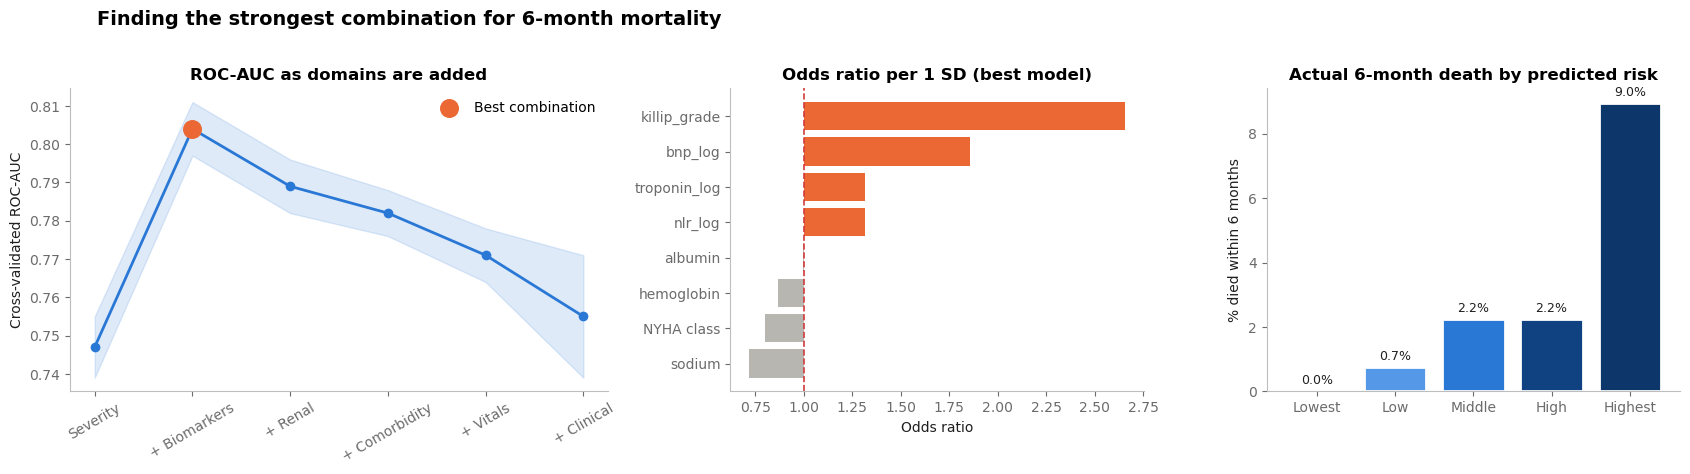

In [32]:
# Best combination = Severity + Biomarkers. Which markers inside it carry the weight?
best14 = domains["Severity"] + domains["Biomarkers"]
best_res = evaluate(df, best14, target14)
final14 = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                        LogisticRegression(C=0.5, class_weight="balanced", max_iter=3000)).fit(df[best14].astype(float), df[target14])
or14 = np.exp(pd.Series(final14[-1].coef_[0], index=best14)).sort_values()
print("Odds ratio per 1 SD (best model):\n", or14.round(2).sort_values(ascending=False))

df["risk14"] = pd.qcut(best_res["prob"], 5, labels=["Lowest", "Low", "Middle", "High", "Highest"])
g14 = df.groupby("risk14")[target14].agg(["sum", "count", "mean"])
print("\n6-month death by predicted risk group:\n", g14.assign(mean=lambda t: (t["mean"]*100).round(1)))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), gridspec_kw={"width_ratios": [1.3, 1, 1]})
ax[0].plot(steps["Model"], steps["ROC-AUC"], marker="o", color=BLUE, lw=2)
ax[0].fill_between(range(len(steps)), steps["ROC-AUC"] - steps["± SD"], steps["ROC-AUC"] + steps["± SD"], color=BLUE, alpha=0.15)
best_i = steps["ROC-AUC"].idxmax()
ax[0].scatter(best_i, steps["ROC-AUC"][best_i], s=160, color=ORANGE, zorder=3, label="Best combination")
ax[0].set(title="ROC-AUC as domains are added", ylabel="Cross-validated ROC-AUC"); ax[0].tick_params(axis="x", rotation=30); ax[0].legend()
ax[1].barh(or14.rename({"nyha_cardiac_function_classification": "NYHA class"}).index, or14.values - 1, left=1, color=[ORANGE if v > 1 else NEUTRAL for v in or14.values])
ax[1].axvline(1, color=REF, ls="--", lw=1.2); ax[1].set(title="Odds ratio per 1 SD (best model)", xlabel="Odds ratio")
ax[2].bar(g14.index.astype(str), g14["mean"]*100, color=ramp(5), edgecolor="white", linewidth=2); label_bars(ax[2])
ax[2].set(title="Actual 6-month death by predicted risk", ylabel="% died within 6 months")
suptitle(fig, "Finding the strongest combination for 6-month mortality"); plt.tight_layout(); plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>We reject H0. Severity alone gives a ROC-AUC of 0.75, and adding the biomarker panel lifts it to <b>0.80, the best combination (8 markers)</b>. Adding renal, comorbidity, vital-sign and clinical domains after that <b>lowers</b> performance step by step, down to 0.76 with all 24 markers. Those domains repeat information the model already has: kidney strain and fluid overload are already reflected in BNP and Killip grade, and with only 57 deaths, every extra marker adds noise. Inside the best model, <b>Killip grade (OR 2.66 per SD) and BNP (OR 1.86)</b> carry most of the weight, followed by troponin and NLR (OR 1.32 each). Higher sodium is protective (OR 0.72), meaning low sodium raises risk. NYHA has an OR below 1 only because it overlaps with Killip once both are in the model. The top fifth of predicted risk holds <b>36 of the 57 deaths (63%)</b>, and the lowest fifth had none. <b>A bedside severity grade plus one blood panel is enough</b>; collecting more domains does not help.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q15. Can patients' previous cardiac history, together with their current clinical severity, be used to predict the likelihood of in-hospital mortality?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>in_hospital_death (defined below)</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Markers used:</b> <code>History: myocardial_infarction, congestive_heart_failure, peripheral_vascular_disease, cerebrovascular_disease, right_or_both_hf | Current severity: nyha_cardiac_function_classification, killip_grade</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Admission notes give a lot of space to past cardiac history (old heart attack, earlier heart failure, vascular disease), and doctors often treat these patients as higher risk. Current severity describes what the heart is doing today: NYHA class for symptoms and Killip grade for congestion and shock. This question tests which of the two actually tells us who will die in hospital, and whether using both is better than using severity alone.</b></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Hypothesis</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>H0:</b> Cardiac history adds no predictive value for in-hospital mortality beyond current severity (ROC-AUC of history + severity ≤ severity alone).<br><b>H1:</b> Cardiac history together with current severity predicts in-hospital mortality better than current severity alone.</i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Model choice</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Logistic regression</b> is used because the question is about comparing groups of markers, and logistic regression shows the direction and size of each marker's effect. Three nested models are compared (history only, severity only, history + severity) with repeated 5-fold cross-validation.</i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Defining in-hospital death</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i>Only 11 patients are recorded as "Dead" during hospitalisation, which is too few to build any model. But 20 patients who left <b>against medical advice</b> died within 0–2 days of leaving (median 0 days). This pattern usually means the family took home a patient who was already dying. These patients are counted as in-hospital deaths, which gives 31 events.</i></p>

In [33]:
dama_died = ((df["outcome_during_hospitalization"] == "DischargeAgainstOrder") & (df["death_within_28_days"] == 1))
print("Days between leaving and death (left against advice and died):")
print((df.loc[dama_died, "time_of_death__days_from_admission"] - df.loc[dama_died, "dischargeday"]).describe().round(1))

df["in_hospital_death"] = ((df["outcome_during_hospitalization"] == "Dead") |
                           (dama_died & (df["time_of_death__days_from_admission"] - df["dischargeday"] <= 2))).astype(int)
print("\nRecorded in-hospital deaths:", (df["outcome_during_hospitalization"] == "Dead").sum(),
      "| After adding deaths within 2 days of leaving against advice:", df["in_hospital_death"].sum())

Days between leaving and death (left against advice and died):
count    20.0
mean      0.6
std       0.7
min       0.0
25%       0.0
50%       0.0
75%       1.0
max       2.0
dtype: float64

Recorded in-hospital deaths: 11 | After adding deaths within 2 days of leaving against advice: 31


In [34]:
target15 = "in_hospital_death"
history = ["myocardial_infarction", "congestive_heart_failure", "peripheral_vascular_disease",
           "cerebrovascular_disease", "right_or_both_hf"]
severity = ["nyha_cardiac_function_classification", "killip_grade"]

models15 = {"History only": history, "Severity only": severity, "History + severity": history + severity}
res15 = pd.DataFrame({k: evaluate(df, v, target15, repeats=10) for k, v in models15.items()}).T[["ROC-AUC", "± SD", "PR-AUC", "Event rate"]]
print(res15)

# Death rate with / without each history item, and by severity level
hist_rates = pd.DataFrame({h: [df.loc[df[h] == 0, target15].mean()*100, df.loc[df[h] == 1, target15].mean()*100,
                               df[h].mean()*100] for h in history}, index=["Without (%)", "With (%)", "Patients with it (%)"]).T.round(1)
print("\n", hist_rates)
print("\nDeath % by Killip grade:\n", df.groupby("killip_grade")[target15].mean().mul(100).round(1))
print("\nDeath % by NYHA class:\n", df.groupby("nyha_cardiac_function_classification")[target15].mean().mul(100).round(1))

                   ROC-AUC   ± SD PR-AUC Event rate
History only         0.486  0.052  0.017      0.015
Severity only        0.869  0.007  0.172      0.015
History + severity   0.844   0.01  0.186      0.015

                              Without (%)  With (%)  Patients with it (%)
myocardial_infarction                1.5       2.1                   7.1
congestive_heart_failure             0.7       1.6                  93.2
peripheral_vascular_disease          1.5       2.0                   5.0
cerebrovascular_disease              1.4       3.3                   7.5
right_or_both_hf                     2.1       1.4                  76.2

Death % by Killip grade:
 killip_grade
1     0.0
2     0.6
3     2.6
4    25.0
Name: in_hospital_death, dtype: float64

Death % by NYHA class:
 nyha_cardiac_function_classification
2    0.6
3    0.3
4    4.2
Name: in_hospital_death, dtype: float64


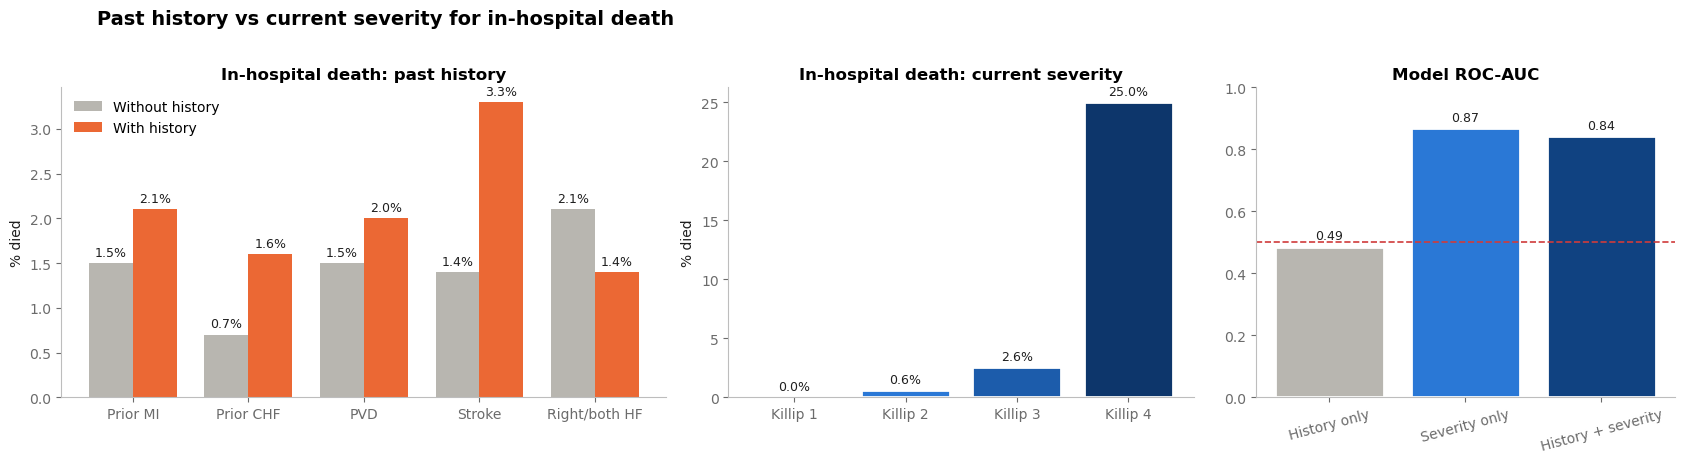

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [1.3, 1, 0.9]})
x = np.arange(len(hist_rates)); w = 0.38
ax[0].bar(x - w/2, hist_rates["Without (%)"], w, color=NEUTRAL, label="Without history")
ax[0].bar(x + w/2, hist_rates["With (%)"], w, color=ORANGE, label="With history"); label_bars(ax[0])
ax[0].set_xticks(x, ["Prior MI", "Prior CHF", "PVD", "Stroke", "Right/both HF"])
ax[0].set(title="In-hospital death: past history", ylabel="% died"); ax[0].legend()
kil = df.groupby("killip_grade")[target15].mean().mul(100)
ax[1].bar([f"Killip {k}" for k in kil.index], kil, color=ramp(4), edgecolor="white", linewidth=2); label_bars(ax[1])
ax[1].set(title="In-hospital death: current severity", ylabel="% died")
ax[2].bar(res15.index, res15["ROC-AUC"], color=[NEUTRAL, BLUE, RAMP[4]], edgecolor="white", linewidth=2)
label_bars(ax[2], "{:.2f}"); ax[2].axhline(0.5, color=REF, ls="--", lw=1.2)
ax[2].set(title="Model ROC-AUC", ylim=(0, 1)); ax[2].tick_params(axis="x", rotation=15)
suptitle(fig, "Past history vs current severity for in-hospital death"); plt.tight_layout(); plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>We fail to reject H0. Cardiac history on its own predicts in-hospital death <b>no better than a coin toss</b> (ROC-AUC 0.49). Current severity alone reaches <b>0.87</b>, and adding history to it makes the model slightly <b>worse</b> (0.84). History items change the death rate very little (prior MI 2.1% vs 1.5%). Prior heart failure is present in 93% of patients, so it cannot tell patients apart, and right-sided or both-sided failure is even linked to a slightly lower death rate. Current severity, in contrast, ranges from <b>0% deaths at Killip grade 1 (none of 527 patients) to 25% at grade 4</b>. The patient's diagnosis history matters less than <b>what the heart is doing at admission</b>, so risk checks at admission should be built on current severity, not on the past-history section of the notes.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q16. Can inflammatory biomarkers, including hs-CRP, WBC, and NLR, be used to predict the risk of in-hospital and 28-day mortality in patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Target:</b> <code>in_hospital_death and death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Markers used:</b> <code>hs_crp_log (+ hs_crp_missing flag), wbc_log, nlr_log</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>In heart failure, a congested gut and stressed heart release inflammatory signals, and infection is one of the most common triggers of an acute episode. hs-CRP measures inflammation directly. WBC shows the overall immune response. NLR shows the balance between neutrophils (which rise with stress and infection) and lymphocytes (which fall with stress hormones). If these markers predict early death, they could add a cheap blood test to the admission risk check. It also matters <b>which marker is practical</b>: a marker is only useful at the bedside if it is measured for most patients.</b></i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Hypothesis</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>H0:</b> hs-CRP, WBC and NLR are not associated with in-hospital or 28-day mortality (ROC-AUC = 0.5).<br><b>H1:</b> Higher inflammatory markers predict in-hospital and 28-day mortality (ROC-AUC > 0.5), and at least one marker is useful on its own.</i></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Model choice</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Logistic regression</b> on the log-transformed markers, so the result can be read as an odds ratio for each marker. hs-CRP is missing for about half the patients, so its missing values are filled with the median and a <b>missing flag</b> is added. This lets the model use hs-CRP without dropping half the patients. Each marker is also tested alone to see which one carries the signal.</i></p>

In [36]:
print("Missing values (% of patients):")
print((df[["hs_crp", "white_blood_cell", "nlr"]].isna().mean()*100).round(1), "\n")

targets16 = {"In-hospital death": "in_hospital_death", "28-day death": "death_within_28_days"}
marker_sets = {"All three": ["hs_crp_log", "hs_crp_missing", "wbc_log", "nlr_log"],
               "NLR only": ["nlr_log"], "WBC only": ["wbc_log"], "hs-CRP only": ["hs_crp_log", "hs_crp_missing"]}
rows = []
for tname, t in targets16.items():
    for mname, cols in marker_sets.items():
        r = evaluate(df, cols, t, repeats=10)
        rows.append({"Outcome": tname, "Markers": mname, "ROC-AUC": r["ROC-AUC"], "± SD": r["± SD"], "PR-AUC": r["PR-AUC"], "Event rate": r["Event rate"]})
res16 = pd.DataFrame(rows)
print(res16.to_string(index=False))

# Odds ratio per 1 log-unit (patients with complete NLR and WBC)
lr16 = LogisticRegression(C=100, max_iter=3000).fit(df[["nlr_log", "wbc_log"]].fillna(df[["nlr_log", "wbc_log"]].median()), df["death_within_28_days"])
print("\nOdds ratio per 1 log-unit (28-day death):", dict(zip(["NLR", "WBC"], np.exp(lr16.coef_[0]).round(2))))

df["nlr_quartile"] = pd.qcut(df["nlr"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
nlr_q = df.groupby("nlr_quartile")[["in_hospital_death", "death_within_28_days"]].mean().mul(100)
print("\nDeath % by NLR quartile:\n", nlr_q.round(1))
print("\nNLR quartile cut-offs:", df["nlr"].quantile([.25, .5, .75]).round(2).tolist())

Missing values (% of patients):
hs_crp              53.1
white_blood_cell     1.3
nlr                  1.3
dtype: float64 

          Outcome     Markers  ROC-AUC  ± SD  PR-AUC  Event rate
In-hospital death   All three    0.708 0.010   0.041       0.015
In-hospital death    NLR only    0.724 0.007   0.047       0.015
In-hospital death    WBC only    0.667 0.006   0.034       0.015
In-hospital death hs-CRP only    0.548 0.014   0.026       0.015
     28-day death   All three    0.712 0.007   0.043       0.018
     28-day death    NLR only    0.695 0.003   0.048       0.018
     28-day death    WBC only    0.655 0.005   0.038       0.018
     28-day death hs-CRP only    0.572 0.015   0.035       0.018

Odds ratio per 1 log-unit (28-day death): {'NLR': np.float64(1.98), 'WBC': np.float64(1.89)}

Death % by NLR quartile:
               in_hospital_death  death_within_28_days
nlr_quartile                                         
Q1 (lowest)                 0.2                   0.4
Q2      

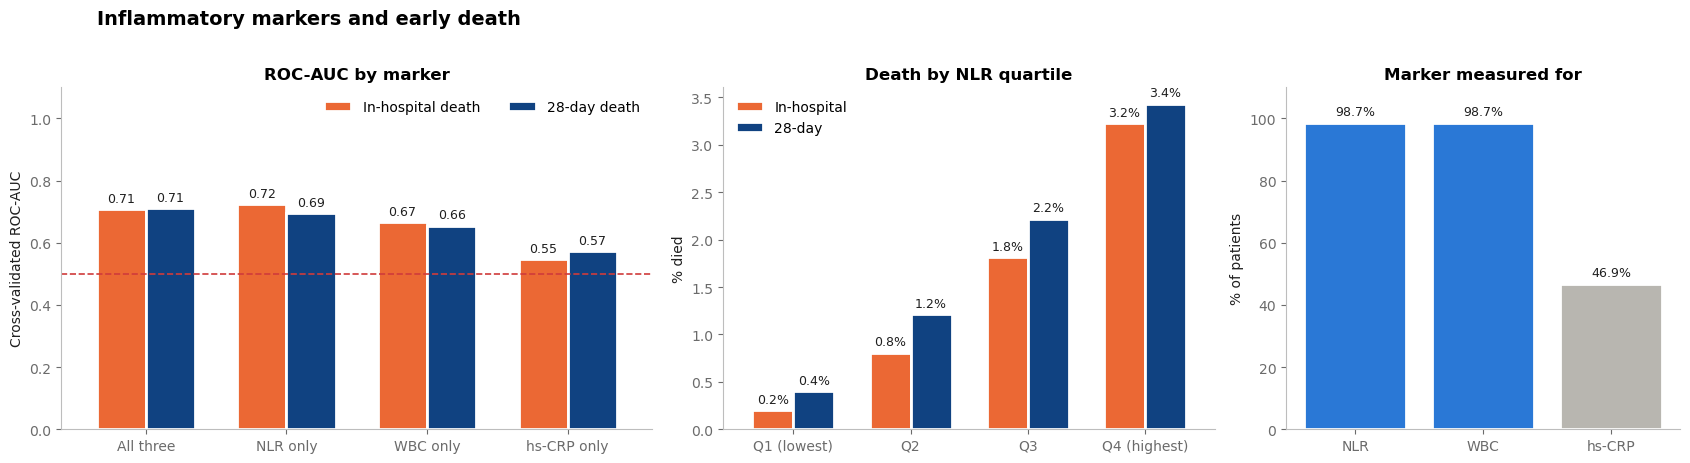

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [1.2, 1, 0.8]})
piv = res16.pivot(index="Markers", columns="Outcome", values="ROC-AUC").reindex(["All three", "NLR only", "WBC only", "hs-CRP only"])
piv[["In-hospital death", "28-day death"]].plot(kind="bar", ax=ax[0], color=[ORANGE, RAMP[4]], rot=0, width=0.7, edgecolor="white", linewidth=2)
label_bars(ax[0], "{:.2f}"); ax[0].axhline(0.5, color=REF, ls="--", lw=1.2)
ax[0].set(title="ROC-AUC by marker", ylabel="Cross-validated ROC-AUC", ylim=(0, 1.1), xlabel=""); ax[0].legend(loc="upper right", ncol=2)
nlr_q.plot(kind="bar", ax=ax[1], color=[ORANGE, RAMP[4]], rot=0, width=0.7, edgecolor="white", linewidth=2)
label_bars(ax[1]); ax[1].set(title="Death by NLR quartile", ylabel="% died", xlabel=""); ax[1].legend(["In-hospital", "28-day"])
avail = (df[["nlr", "white_blood_cell", "hs_crp"]].notna().mean()*100).rename({"nlr": "NLR", "white_blood_cell": "WBC", "hs_crp": "hs-CRP"})
ax[2].bar(avail.index, avail, color=[BLUE, BLUE, NEUTRAL], edgecolor="white", linewidth=2); label_bars(ax[2])
ax[2].set(title="Marker measured for", ylabel="% of patients", ylim=(0, 110))
suptitle(fig, "Inflammatory markers and early death"); plt.tight_layout(); plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>We reject H0 for NLR and WBC. NLR alone (ROC-AUC <b>0.72</b> in-hospital, 0.69 at 28 days) does as well as all three markers together (0.71). Each 1-unit rise in log-NLR roughly <b>doubles the odds</b> of 28-day death (OR 1.98). The risk climbs steadily across NLR quartiles, from 0.4% to <b>3.4%</b> for 28-day death and from 0.2% to 3.2% for in-hospital death. hs-CRP is almost useless here (ROC-AUC 0.55–0.57), and the reason is practical rather than biological: it was <b>not measured for 53% of patients</b>, while NLR and WBC are available for 98.7%. NLR comes free with the routine blood count taken at every admission, so <b>NLR ≥ 8.68 (the top quartile)</b> can serve as a simple inflammation flag.</b></i></p>